In [ ]:
!pip install -q transformers datasets accelerate
!pip install -q spacy wordcloud
!pip install -q yfinance
!python -m spacy download en_core_web_sm -q
!pip install -q kaggle
!pip install -q pysentiment2
!pip install -q feedparser

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 68.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 80.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 7.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import re, os, warnings
import nltk, spacy, torch, feedparser
import joblib
import pysentiment2 as ps

import tensorflow as tf

from google.colab import drive
from datetime import datetime, timedelta
from google.colab import files
from datasets import Dataset
from urllib.parse import quote

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, TrainingArguments, Trainer

warnings.filterwarnings('ignore')

# ── NLTK Downloads + spaCy ────────────────────────────────────────────────────
nltk.download('punkt',                      quiet=True)
nltk.download('stopwords',                  quiet=True)
nltk.download('wordnet',                    quiet=True)
nltk.download('punkt_tab',                  quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

nlp = spacy.load('en_core_web_sm')

# ── CHECK: are we resuming or training from scratch? ──────────────────────────
SAVE_DIR = '/content/drive/MyDrive/NLPQ/checkpoints/'

drive.mount('/content/drive', force_remount=True)

RESUMING = os.path.exists(SAVE_DIR + 'tfidf_vectorizer.pkl')
print(f'Mode: {"RESUMING from checkpoint" if RESUMING else "TRAINING from scratch"}')

if RESUMING:
    print('\nLoading saved weights...')

    # Classical models
    vectorizer   = joblib.load(SAVE_DIR + 'tfidf_vectorizer.pkl')
    model_lr     = joblib.load(SAVE_DIR + 'model_lr.pkl')
    model_svm    = joblib.load(SAVE_DIR + 'model_svm.pkl')
    model_mnb    = joblib.load(SAVE_DIR + 'model_mnb.pkl')
    meta_learner = joblib.load(SAVE_DIR + 'meta_learner.pkl')
    le           = joblib.load(SAVE_DIR + 'label_encoder.pkl')
    print('Classical models loaded')

    # BiLSTM
    VOCAB_SIZE      = 8000
    model_bilstm    = load_model(SAVE_DIR + 'bilstm_model.keras')
    keras_tokenizer = joblib.load(SAVE_DIR + 'keras_tokenizer.pkl')
    print('BiLSTM loaded')

    # DistilBERT
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    bert_tokenizer   = DistilBertTokenizerFast.from_pretrained(SAVE_DIR + 'distilbert_model')
    model_distilbert = DistilBertForSequenceClassification.from_pretrained(SAVE_DIR + 'distilbert_model')
    model_distilbert.to(device)
    model_distilbert.eval()
    print(f'DistilBERT loaded ({device})')

    # Probability arrays + labels
    prob_distilbert = np.load(SAVE_DIR + 'prob_distilbert.npy')
    prob_bilstm     = np.load(SAVE_DIR + 'prob_bilstm.npy')
    y_test          = np.load(SAVE_DIR + 'y_test.npy')
    y_train         = np.load(SAVE_DIR + 'y_train.npy')
    print('Probability arrays loaded')

    # Text arrays + rebuild TF-IDF
    X_text_train  = pd.Series(joblib.load(SAVE_DIR + 'X_text_train.pkl'))
    X_text_test   = pd.Series(joblib.load(SAVE_DIR + 'X_text_test.pkl'))
    X_tfidf_train = vectorizer.transform(X_text_train)
    X_tfidf_test  = vectorizer.transform(X_text_test)
    print('TF-IDF matrices rebuilt')

    # Redefine preprocessing functions
    lemmatizer        = WordNetLemmatizer()
    GENERIC_STOPWORDS = set(stopwords.words('english'))
    PRESERVE          = {'not', 'no', 'nor', 'up', 'down', 'above', 'below', 'against', 'over', 'under'}
    FINANCE_STOPWORDS = GENERIC_STOPWORDS - PRESERVE

    def preprocess_finance(text):
        text   = str(text).lower()
        text   = re.sub(r'\$[a-zA-Z]+',           'stockticker',  text)
        text   = re.sub(r'\d+\.?\d*%',            'percentvalue', text)
        text   = re.sub(r'\$\d+\.?\d*[bBmMkK]?',  'dollarvalue',  text)
        tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", text)
        tokens = [t for t in tokens if t not in FINANCE_STOPWORDS and len(t) > 2]
        return ' '.join(tokens)

    POS_FEATURE_NAMES = ['verb_ratio', 'adj_ratio', 'noun_ratio', 'adv_ratio', 'neg_count']

    def extract_pos_features(text):
        doc    = nlp(str(text))[:512]
        tokens = [t for t in doc if not t.is_space]
        n      = max(len(tokens), 1)
        return [
            sum(1 for t in tokens if t.pos_ == 'VERB') / n,
            sum(1 for t in tokens if t.pos_ == 'ADJ')  / n,
            sum(1 for t in tokens if t.pos_ == 'NOUN') / n,
            sum(1 for t in tokens if t.pos_ == 'ADV')  / n,
            sum(1 for t in tokens if t.dep_ == 'neg')  / n,
        ]

    lm_scorer   = ps.LM()
    LM_POSITIVE = {'above','accomplish','achievement','adequate','advancement','beneficial','best','boom','breakthrough','bullish','capable','confident','consistent','decisive','efficient','encouraging','exceptional','excellent','exceed','favorable','gain','gains','grew','growth','improve','improved','improvement','increasing','innovative','leading','optimal','outperform','positive','profitable','progress','rally','record','recover','recovery','resilient','rise','rises','robust','soar','soared','stable','strength','strong','success','successful','surge','surged','surpass','sustainable','thriving','top','upward','win'}
    LM_NEGATIVE = {'abandon','adverse','bankrupt','bankruptcy','bearish','below','collapse','concern','concerns','crash','crisis','cut','decline','declined','deficit','deteriorate','difficult','disappointing','distress','doubt','downgrade','downturn','drop','dropped','fail','failed','failure','fall','falling','fell','fragile','fraud','halt','impair','inadequate','inflationary','instability','insufficient','layoff','layoffs','litigation','loss','losses','low','miss','missed','negative','penalty','plummet','plummeted','poor','recession','restructure','risk','risks','selloff','shutdown','slump','stagnant','turmoil','uncertain','uncertainty','unfavorable','volatile','volatility','warn','warning','weak','weakness','writedown','writeoff'}
    LM_FEATURE_NAMES = ['lm_pos', 'lm_neg', 'lm_polarity', 'manual_pos', 'manual_neg']

    def extract_lm_features(text):
        tokens = lm_scorer.tokenize(text)
        score  = lm_scorer.get_score(tokens)
        n      = max(len(tokens), 1)
        words  = set(text.lower().split())
        return [
            score['Positive'] / n,
            score['Negative'] / n,
            score['Polarity'],
            len(words & LM_POSITIVE) / n,
            len(words & LM_NEGATIVE) / n,
        ]

    print('\t\tPreprocessing functions redefined')

    print()
    print('═' * 50)
    print('  Ready. Skip to Act 3.')
    print('═' * 50)
    print(f'\t\tLabels   : {dict(zip(le.classes_, le.transform(le.classes_)))}')
    print(f'\t\tTF-IDF   : {X_tfidf_train.shape[1]:,} features')
    print(f'\t\tTest set : {len(y_test):,} samples')
    print(f'\t\tDevice   : {device}')

else:
    print('No checkpoint found — run cells 2 onwards to train from scratch.')
    print(f'Checkpoints will be saved to: {SAVE_DIR}')

Mounted at /content/drive
Mode: TRAINING from scratch
No checkpoint found — run cells 2 onwards to train from scratch.
Checkpoints will be saved to: /content/drive/MyDrive/NLPQ/checkpoints/


In [ ]:
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok = True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 0o600)

Saving kaggle.json to kaggle.json


In [ ]:
os.makedirs('/content/data', exist_ok = True)

# financial phrasebank
!kaggle datasets download -d ankurzing/sentiment-analysis-for-financial-news -p /content/data/phrasebank --unzip -q

# stockmarket sentiment
!kaggle datasets download -d yash612/stockmarket-sentiment-dataset -p /content/data/stockmarket --unzip -q


for folder in ['phrasebank', 'stockmarket']:
  print(f"\t{folder}: {os.listdir(f"/content/data/{folder}")}")

Dataset URL: https://www.kaggle.com/datasets/ankurzing/sentiment-analysis-for-financial-news
License(s): CC-BY-NC-SA-4.0
Dataset URL: https://www.kaggle.com/datasets/yash612/stockmarket-sentiment-dataset
License(s): copyright-authors
	phrasebank: ['all-data.csv', 'FinancialPhraseBank']
	stockmarket: ['stock_data.csv']


In [ ]:
# Phrasebank
pb_raw = pd.read_csv('/content/data/phrasebank/all-data.csv', encoding = 'latin-1', header = None, names = ['Sentiment', 'text'])
print("---PHASEBANK---")
print("Shape: ", pb_raw.shape)
print(pb_raw.head(5))
print("Labels:", pb_raw['Sentiment'].unique())

# Stock Market Sentinment
sm_raw = pd.read_csv('/content/data/stockmarket/stock_data.csv')
print("---STOCKMARKET---")
print("Shape: ", sm_raw.shape)
print(sm_raw.head(5))
print("Columns:", sm_raw.columns.tolist())
print("Labels:", sm_raw.iloc[:, -1].unique())

---PHASEBANK---
Shape:  (4846, 2)
  Sentiment                                               text
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...
Labels: ['neutral' 'negative' 'positive']
---STOCKMARKET---
Shape:  (5791, 2)
                                                Text  Sentiment
0  Kickers on my watchlist XIDE TIT SOQ PNK CPW B...          1
1  user: AAP MOVIE. 55% return for the FEA/GEED i...          1
2  user I'd be afraid to short AMZN - they are lo...          1
3                                  MNTA Over 12.00            1
4                                   OI  Over 21.37            1
Columns: ['Text', 'Sentiment']
Labels: [ 1 -1]


In [ ]:
# feature engineering -> adding a column for source
# phasebank
pb = pb_raw.copy()
pb['Sentinment'] = pb['Sentiment'].str.strip().str.lower()
pb['Source'] = 'phrasebank'

print("PhraseBank")
print(pb['Sentiment'].value_counts())

# stock market sentiment
sm = sm_raw.copy()
SM_LABEL_MAP = {
    1: 'positive',
    -1: 'negative'
}
sm = pd.DataFrame({
    'text': sm['Text'].astype(str),
    'Sentiment': sm['Sentiment'].map(SM_LABEL_MAP)
})
sm['Source'] = 'stockmarket'

print("\nStockMarket")
print(sm['Sentiment'].value_counts())


PhraseBank
Sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

StockMarket
Sentiment
positive    3685
negative    2106
Name: count, dtype: int64


In [ ]:
# merging and cleaning
df = pd.concat([pb, sm], ignore_index = True)

# strip whitespace
df['text'] = df['text'].str.strip()

# remove dups sentences
before = len(df)
df = df.drop_duplicates(subset = 'text')
print(f"Duplicate removed: {before - len(df):,}")

# drop rows with missing values
df = df.dropna(subset = ['text', 'Sentiment'])

# keeping valid labels only
df = df[df['Sentiment'].isin({'negative', 'neutral', 'positive'})]

print(f"Combined dataset: {len(df):,} samples")
print("\nLabel Distribution")
print(df['Sentiment'].value_counts())
print("\nSamples per Source:")
print(df.groupby('Source')['Sentiment'].value_counts().unstack(fill_value = 0))

Duplicate removed: 12
Combined dataset: 10,625 samples

Label Distribution
Sentiment
positive    5045
neutral     2872
negative    2708
Name: count, dtype: int64

Samples per Source:
Sentiment    negative  neutral  positive
Source                                  
phrasebank        604     2872      1362
stockmarket      2104        0      3683


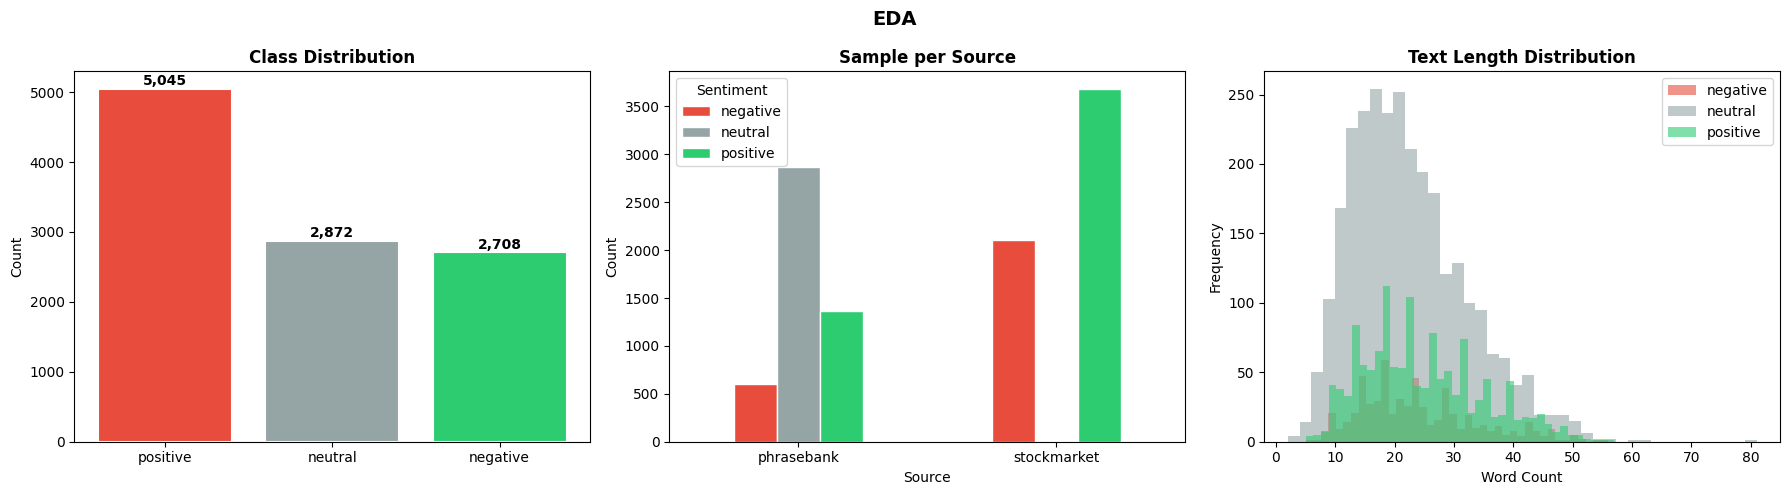

Average word count per class: 
Sentiment
negative    16.3
neutral     22.2
positive    16.9
Name: word_count, dtype: float64


In [ ]:
# EDA

# red = negative, grey = neutral, green = positive
COLOURS = ['#E74C3C', '#95A5A6', '#2ECC71']

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# class distribution plot
counts = df['Sentiment'].value_counts()
axes[0].bar(counts.index, counts.values, color = COLOURS, edgecolor = 'white', linewidth = 1.5)
for i, (label, val) in enumerate(counts.items()):
  axes[0].text(i, val + 50, f"{val:,}", ha = 'center', fontweight = 'bold')
axes[0].set_title("Class Distribution", fontweight = 'bold')
axes[0].set_ylabel("Count")

# source breakdown
source_sent = df.groupby(['Source', 'Sentiment']).size().unstack(fill_value = 0)
source_sent.plot(kind = 'bar', ax = axes[1], color = COLOURS, edgecolor = 'white')
axes[1].set_title("Sample per Source", fontweight = 'bold')
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis = "x", rotation = 0)
axes[1].legend(title = "Sentiment")

# text length distribution
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
for sent, colour in zip(['negative', 'neutral', 'positive'], COLOURS):
  subset = df[df['Sentinment'] == sent]['word_count']
  axes[2].hist(subset, bins = 40, alpha = 0.6, label = sent, color = colour)
axes[2].set_title("Text Length Distribution", fontweight = 'bold')
axes[2].set_xlabel("Word Count")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.suptitle("EDA", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

print("Average word count per class: ")
print(df.groupby('Sentiment')['word_count'].mean().round(1))

neutral sentiments is longer, could be due to having more descriptiove analytical sentences

negative and positive sentiments are more direct

In [ ]:
# preprocessing

lemmatizer = WordNetLemmatizer()

GENERIC_STOPWORDS  = set(stopwords.words('english'))
PRESERVE = {
    'not', 'no', 'nor', 'up', 'down', 'above', 'below', 'against', 'over', 'under'
}

FINANCE_STOPWORDS = GENERIC_STOPWORDS - PRESERVE

print(f"Generic Stopwords: {len(GENERIC_STOPWORDS)}")
print(f"Preserved Words: {PRESERVE}")
print(f"Finance Stopwords: {len(FINANCE_STOPWORDS)}")


def preprocess_finance(text):
  text = str(text).lower()

  # normalizing

  # stock ticker
  text = re.sub(r'\$[a-zA-Z]+', 'stockticker', text)
  # percent values
  text = re.sub(r'\d+\.?\d*%', 'percentvalue', text)
  # dollar values
  text = re.sub(r'\$\d+\.?\d*[bBmMkK]?', 'dollarvalue', text)

  # removes punctuation and numbers
  tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", text)

  tokens = [t for t in tokens if t not in FINANCE_STOPWORDS]

  tokens = [t for t in tokens if len(t) > 2]

  return ' '.join(tokens)

test_sentences = [
    "Apple's stock surged 12.5% after beating earnings expectations.",
    "The company was not profitable and may face further decline.",
    "$TSLA dropped below $200 amid bearish market sentiment."
]

print('Preprocessing test:')
for s in test_sentences:
  print(f"\n\tOriginal : {s}")
  print(f"\tCleaned : {preprocess_finance(s)}")


print("Preprocessing Text:")
df['text_clean'] = df['text'].apply(preprocess_finance)

print("Sample Comparisons:")
for i in df.sample(3, random_state = 123).index:
  print(f"\n\tRaw\t:\t{df.loc[i, 'text'][:80]}")
  print(f"\tCleaned\t:\t{df.loc[i, 'text_clean'][:80]}")

Generic Stopwords: 198
Preserved Words: {'above', 'down', 'over', 'nor', 'up', 'not', 'against', 'no', 'below', 'under'}
Finance Stopwords: 188
Preprocessing test:

	Original : Apple's stock surged 12.5% after beating earnings expectations.
	Cleaned : apple's stock surged percentvalue beating earnings expectations

	Original : The company was not profitable and may face further decline.
	Cleaned : company not profitable may face decline

	Original : $TSLA dropped below $200 amid bearish market sentiment.
	Cleaned : stockticker dropped below dollarvalue amid bearish market sentiment
Preprocessing Text:
Sample Comparisons:

	Raw	:	AAP quietly show me consistent 120k 4every 2min print will send me back to cash 
	Cleaned	:	aap quietly show consistent every min print send back cash spike single bar

	Raw	:	Talking headsCNBC talking the GOOG~ AAP rotation suggest max target 840 unless s
	Cleaned	:	talking headscnbc talking goog aap rotation suggest max target unless strong mov

	Raw	:	Trying

In [ ]:
# POS Feature Extraction

def extract_pos_features(text):
  # cap at 512 characters
  doc = nlp(str(text))[:512]
  tokens = [t for t in doc if not t.is_space]
  n = max(len(tokens), 1)

  verb_ratio = sum(1 for t in tokens if t.pos_ == 'VERB') /n
  adj_ratio = sum(1 for t in tokens if t.pos_ == 'ADJ') /n
  noun_ratio = sum(1 for t in tokens if t.pos_ == 'NOUN') /n
  adv_ratio = sum(1 for t in tokens if t.pos_ == 'ADV') /n

  neg_count = sum(1 for t in tokens if t.dep_ == 'neg') /n

  return [verb_ratio, adj_ratio, noun_ratio, adv_ratio, neg_count]

POS_FEATURE_NAMES = ['verb_ratio', 'adj_ratio', 'noun_ratio', 'adv_ratio', 'neg_count']

test = "The company was not profitable and revenues fell sharply"
print("Test Sentence: ", test)
print("POS Features: ", extract_pos_features(test))
print("Feature Names: ", POS_FEATURE_NAMES)

Test Sentence:  The company was not profitable and revenues fell sharply
POS Features:  [0.1111111111111111, 0.1111111111111111, 0.2222222222222222, 0.1111111111111111, 0.1111111111111111]
Feature Names:  ['verb_ratio', 'adj_ratio', 'noun_ratio', 'adv_ratio', 'neg_count']


In [ ]:
# what spacy is doing

test = "The company was not profitable and revenues fell sharply."
doc = nlp(test)

print("Token\t\t\t| POS\t\t\t| DEP")
print("-" * 80)
for t in doc:
  print(f"{t.text}\t\t\t| {t.pos_:6s}\t\t\t| {t.dep_}")

Token			| POS			| DEP
--------------------------------------------------------------------------------
The			| DET   			| det
company			| NOUN  			| nsubj
was			| AUX   			| ROOT
not			| PART  			| neg
profitable			| ADJ   			| acomp
and			| CCONJ 			| cc
revenues			| NOUN  			| nsubj
fell			| VERB  			| conj
sharply			| ADV   			| advmod
.			| PUNCT 			| punct


In [ ]:
# apply POS to dataset

print("Extracting POS features")

pos_features = df['text_clean'].apply(extract_pos_features)

pos_df = pd.DataFrame(
    pos_features.tolist(),
    columns = POS_FEATURE_NAMES,
    index =  df.index
)

print(f"POS feature matrix shape: {pos_df.shape}")
print("\nPOS Analysis:")
pos_analysis = pos_df.copy()
pos_analysis['Sentiment'] = df['Sentiment'].values
print(pos_analysis.groupby('Sentiment')[POS_FEATURE_NAMES].mean().round(4))

Extracting POS features
POS feature matrix shape: (10625, 5)

POS Analysis:
           verb_ratio  adj_ratio  noun_ratio  adv_ratio  neg_count
Sentiment                                                         
negative       0.1810     0.1321      0.4060     0.0466     0.0050
neutral        0.1734     0.1135      0.4775     0.0302     0.0054
positive       0.1871     0.1263      0.4131     0.0526     0.0032


In [ ]:
# Loughran-McDonald Lexicon Features

# https://sraf.nd.edu/loughranmcdonald-master-dictionary/

lm = ps.LM()

test_sentences = [
    "The company reported strong earnings and record revenue growth.",
    "Bankruptcy fears and massive losses triggered a sharp selloff.",
    "The board met to discuss quarterly results and operational updates."
]

for s in test_sentences:
  tokens = lm.tokenize(s)
  score = lm.get_score(tokens)
  print(f"Text\t: {s}")
  print(f"Score\t: {score}")
  print()

Text	: The company reported strong earnings and record revenue growth.
Score	: {'Positive': np.int64(0), 'Negative': np.int64(0), 'Polarity': np.float64(0.0), 'Subjectivity': np.float64(0.0)}

Text	: Bankruptcy fears and massive losses triggered a sharp selloff.
Score	: {'Positive': np.int64(0), 'Negative': np.int64(2), 'Polarity': np.float64(-0.99999950000025), 'Subjectivity': np.float64(0.399999920000016)}

Text	: The board met to discuss quarterly results and operational updates.
Score	: {'Positive': np.int64(0), 'Negative': np.int64(0), 'Polarity': np.float64(0.0), 'Subjectivity': np.float64(0.0)}



In [ ]:
# combine pysentiment2 and manual list

LM_POSITIVE = {
    'above', 'accomplish', 'achievement', 'adequate', 'advancement',
    'beneficial', 'best', 'boom', 'breakthrough', 'bullish', 'capable',
    'confident', 'consistent', 'decisive', 'efficient', 'encouraging',
    'exceptional', 'excellent', 'exceed', 'favorable', 'gain', 'gains',
    'grew', 'growth', 'improve', 'improved', 'improvement', 'increasing',
    'innovative', 'leading', 'optimal', 'outperform', 'positive', 'profitable',
    'progress', 'rally', 'record', 'recover', 'recovery', 'resilient',
    'rise', 'rises', 'robust', 'soar', 'soared', 'stable', 'strength',
    'strong', 'success', 'successful', 'surge', 'surged', 'surpass',
    'sustainable', 'thriving', 'top', 'upward', 'win'
}

LM_NEGATIVE = {
    'abandon', 'adverse', 'bankrupt', 'bankruptcy', 'bearish', 'below',
    'collapse', 'concern', 'concerns', 'crash', 'crisis', 'cut', 'decline',
    'declined', 'deficit', 'deteriorate', 'difficult', 'disappointing',
    'distress', 'doubt', 'downgrade', 'downturn', 'drop', 'dropped',
    'fail', 'failed', 'failure', 'fall', 'falling', 'fell', 'fragile',
    'fraud', 'halt', 'impair', 'inadequate', 'inflationary', 'instability',
    'insufficient', 'layoff', 'layoffs', 'litigation', 'loss', 'losses',
    'low', 'miss', 'missed', 'negative', 'penalty', 'plummet', 'plummeted',
    'poor', 'recession', 'restructure', 'risk', 'risks', 'selloff',
    'shutdown', 'slump', 'stagnant', 'turmoil', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'warn', 'warning', 'weak',
    'weakness', 'writedown', 'writeoff'
}

def extract_lm_features(text):

  # pysentiment2 score
  tokens = lm.tokenize(text)
  score = lm.get_score(tokens)
  n = max(len(tokens), 1)

  lm_pos = score['Positive'] /n
  lm_neg = score['Negative'] /n
  lm_polarity = score['Polarity']

  # manual lexicon ratios to provide positive coverage
  words = set(text.lower().split())
  manual_pos = len(words & LM_POSITIVE) /n
  manual_neg = len(words & LM_NEGATIVE) /n

  return [lm_pos, lm_neg, lm_polarity, manual_pos, manual_neg]

LM_FEATURE_NAMES = ['lm_pos', 'lm_neg', 'lm_polarity', 'manual_pos', 'manual_neg']

print("Extracting L-M features")
lm_features = df['text_clean'].apply(extract_lm_features)
lm_df = pd.DataFrame(lm_features.tolist(), columns = LM_FEATURE_NAMES, index = df.index)

print("\nMean L-M scores per sentiment class:")
lm_analysis = lm_df.copy()
lm_analysis['Sentiment'] = df['Sentiment'].values
print(lm_analysis.groupby('Sentiment')[LM_FEATURE_NAMES].mean().round(4))

Extracting L-M features

Mean L-M scores per sentiment class:
           lm_pos  lm_neg  lm_polarity  manual_pos  manual_neg
Sentiment                                                     
negative   0.0220  0.0646      -0.2199      0.0113      0.0471
neutral    0.0205  0.0257       0.0002      0.0061      0.0040
positive   0.0320  0.0356       0.0141      0.0303      0.0095


In [ ]:
# combining all features: TF-IDF, POS, L-M

le = LabelEncoder()
y = le.fit_transform(df['Sentiment'])
print("Label Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X_test = df['text_clean']
X_pos = pos_df.values
X_lm = lm_df.values

# train-test split
(X_text_train, X_text_test, X_pos_train, X_pos_test, X_lm_train, X_lm_test, y_train, y_test) = train_test_split(X_test, X_pos, X_lm, y, test_size = 0.2, random_state = 123, stratify = y)

# TD-IDF
vectorizer = TfidfVectorizer(ngram_range = (1, 2), max_features = 15000, sublinear_tf = True, min_df = 2)

X_tfidf_train = vectorizer.fit_transform(X_text_train)
X_tfidf_test = vectorizer.transform(X_text_test)

# combine all 3
X_combined_train = hstack([X_tfidf_train, csr_matrix(X_pos_train), csr_matrix(X_lm_train)])
X_combined_test = hstack([X_tfidf_test, csr_matrix(X_pos_test), csr_matrix(X_lm_test)])

# class weight
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes = classes, y = y_train)
class_weight_dict = dict(zip(classes, class_weights))
sample_weights = np.vectorize(class_weight_dict.get)(y_train)

print(f"Training Samples : {len(y_train):,}")
print(f"Test Samples : {len(y_test):,}")
print(f"TF-IDF Features : {X_tfidf_train.shape[1]:,}")
print(f"Combined Features : {X_combined_train.shape[1]:,}")
print(f"Class Weights : {class_weight_dict}")

Label Mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Training Samples : 8,500
Test Samples : 2,125
TF-IDF Features : 12,792
Combined Features : 12,802
Class Weights : {np.int64(0): np.float64(1.3080947983995075), np.int64(1): np.float64(1.2329561937917028), np.int64(2): np.float64(0.702015196564255)}


In [ ]:
# Training Models (Basic Models: Linear Regression, Support Vector Machine, Multinominal Bayes)

print("Training Basic Models\n")

lr_grid = GridSearchCV(LogisticRegression(max_iter = 1000, class_weight = 'balanced', random_state = 123, solver = 'lbfgs', multi_class = 'multinomial'),
                       # C controls regularisations; higher C, less regularisation
                       {'C': [0.1, 1.0, 10.0]},
                       cv = 3, scoring = 'f1_macro', n_jobs = -1)

lr_grid.fit(X_combined_train, y_train)
model_lr = lr_grid.best_estimator_
print(f"LR -> best C = {lr_grid.best_params_["C"]} | macro-F1 = {lr_grid.best_score_:.4f}")


svm_grid = GridSearchCV(LinearSVC(class_weight = 'balanced', random_state = 123, max_iter = 2000),
                        {'C': [0.1, 1.0, 5.0]},
                        cv = 3, scoring = 'f1_macro', n_jobs = -1)

svm_grid.fit(X_combined_train, y_train)
model_svm = CalibratedClassifierCV(svm_grid.best_estimator_, cv = 'prefit')
model_svm.fit(X_combined_train, y_train)
print(f"SVM -> best C = {svm_grid.best_params_["C"]} | macro-F1 = {svm_grid.best_score_:.4f}")


mnb_grid = GridSearchCV(MultinomialNB(),
                        {'alpha': [0.01, 0.1, 0.5, 1.0]},
                        cv = 3, scoring = 'f1_macro', n_jobs = -1)
mnb_grid.fit(X_tfidf_train, y_train)
model_mnb = mnb_grid.best_estimator_
print(f"MNB -> best alpha = {mnb_grid.best_params_["alpha"]} | macro-F1 = {mnb_grid.best_score_:.4f}")


print("Basic model trained")

Training Basic Models

LR -> best C = 10.0 | macro-F1 = 0.7464
SVM -> best C = 1.0 | macro-F1 = 0.7473
MNB -> best alpha = 0.1 | macro-F1 = 0.7179
Basic model trained


In [ ]:
# evaluate basic models

basic_results = {}

for name, model, X_te in [
    ('LR', model_lr, X_combined_test),
    ('SVM', model_svm, X_combined_test),
    ('MNB', model_mnb, X_tfidf_test),
]:
  preds = model.predict(X_te)
  acc = accuracy_score(y_test, preds)
  wf1 = f1_score(y_test, preds, average = 'weighted')
  mf1 = f1_score(y_test, preds, average = 'macro')

  basic_results[name] = {
      'preds': preds,
      'acc': acc,
      'wf1': wf1,
      'mf1': mf1
  }

  print(f"{name:4s} -> Acc: {acc:.4f} | Weighted F1: {wf1:.4f} | Macro F1: {mf1:.4f}")
  print(classification_report(y_test, preds, target_names = le.classes_))
  print()

LR   -> Acc: 0.7685 | Weighted F1: 0.7681 | Macro F1: 0.7644
              precision    recall  f1-score   support

    negative       0.73      0.72      0.72       542
     neutral       0.74      0.85      0.79       574
    positive       0.81      0.75      0.78      1009

    accuracy                           0.77      2125
   macro avg       0.76      0.77      0.76      2125
weighted avg       0.77      0.77      0.77      2125


SVM  -> Acc: 0.7722 | Weighted F1: 0.7713 | Macro F1: 0.7657
              precision    recall  f1-score   support

    negative       0.76      0.68      0.72       542
     neutral       0.77      0.81      0.79       574
    positive       0.78      0.80      0.79      1009

    accuracy                           0.77      2125
   macro avg       0.77      0.76      0.77      2125
weighted avg       0.77      0.77      0.77      2125


MNB  -> Acc: 0.7294 | Weighted F1: 0.7256 | Macro F1: 0.7196
              precision    recall  f1-score   support

In [ ]:
# BiLSTM

VOCAB_SIZE = 8000
MAX_LEN = 100

keras_tokenizer = KerasTokenizer(num_words = VOCAB_SIZE, oov_token = '<OOV>')
keras_tokenizer.fit_on_texts(X_text_train)

X_seq_train = pad_sequences(keras_tokenizer.texts_to_sequences(X_text_train), maxlen = MAX_LEN, padding = 'post')
X_seq_test = pad_sequences(keras_tokenizer.texts_to_sequences(X_text_test), maxlen = MAX_LEN, padding = 'post')

print(f"Vocabulary Size : {VOCAB_SIZE}")
print(f"Sequence Length : {MAX_LEN}")
print(f"Train Shape : {X_seq_train.shape}")
print(f"Test Shape : {X_seq_test.shape}")

Vocabulary Size : 8000
Sequence Length : 100
Train Shape : (8500, 100)
Test Shape : (2125, 100)


In [ ]:
# BiLSTM built

def build_bilstm():
  model = Sequential([
      Embedding(VOCAB_SIZE, 64, input_length = MAX_LEN),
      Bidirectional(LSTM(64, return_sequences = True, dropout = 0.3, recurrent_dropout = 0.2)),
      Bidirectional(LSTM(32, dropout = 0.3)),
      Dense(64, activation = 'relu', kernel_regularizer = l2(0.001)),
      Dropout(0.4),
      Dense(3, activation = 'softmax')
  ])
  model.compile(
      optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-3),
      loss = 'sparse_categorical_crossentropy',
      metrics = ['accuracy']
  )
  return model

model_bilstm = build_bilstm()
model_bilstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 100s 708ms/step - accuracy: 0.4535 - loss: 1.0432 - val_accuracy: 0.6024 - val_loss: 0.8490 - learning_rate: 0.0010
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 82s 686ms/step - accuracy: 0.7261 - loss: 0.6421 - val_accuracy: 0.7400 - val_loss: 0.6526 - learning_rate: 0.0010
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 82s 686ms/step - accuracy: 0.8442 - loss: 0.4044 - val_accuracy: 0.7565 - val_loss: 0.6508 - learning_rate: 0.0010
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 85s 713ms/step - accuracy: 0.9000 - loss: 0.2735 - val_accuracy: 0.7141 - val_loss: 0.8213 - learning_rate: 0.0010
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.9329 - loss: 0.2045
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
120/120 ━━━━━━━━━━━━━━━━━━━━ 85s 705ms/step - accuracy: 0.9288 - loss: 0.2107 - val_accuracy: 0.7424 - val_loss: 0.8371 - learning_rate: 0.0010
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 142s 707ms/step - accuracy: 0.9

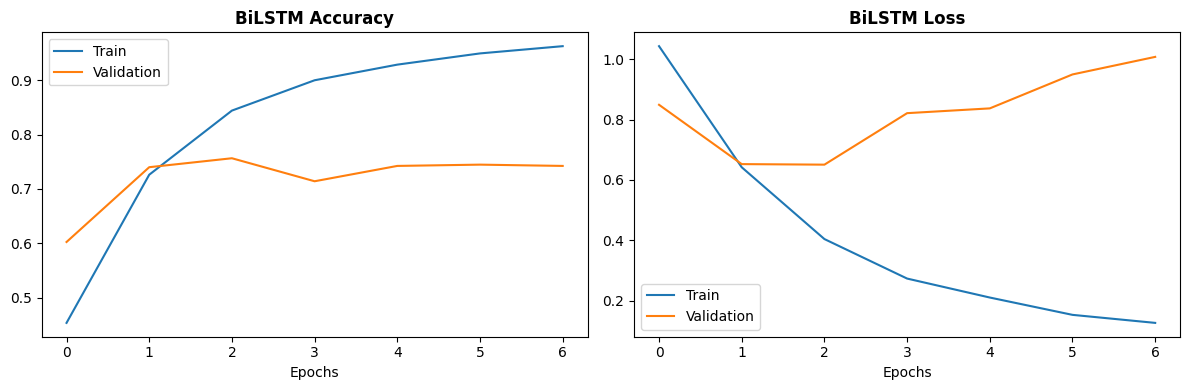


BiLSTM -> Acc: 0.7449  | Macro F1: 0.7406
              precision    recall  f1-score   support

    negative       0.69      0.69      0.69       542
     neutral       0.71      0.85      0.78       574
    positive       0.80      0.72      0.76      1009

    accuracy                           0.74      2125
   macro avg       0.74      0.75      0.74      2125
weighted avg       0.75      0.74      0.74      2125



In [ ]:
# Training of BiLSTM

callbacks = [
    EarlyStopping(monitor = 'val_loss', patience = 4, restore_best_weights = True, verbose = 1),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 2, verbose = 1)
]

history_bilstm = model_bilstm.fit(
    X_seq_train, y_train,
    epochs = 30,
    batch_size = 64,
    validation_split = 0.1,
    class_weight = class_weight_dict,
    callbacks = callbacks,
    verbose = 1
)

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
for ax, metric in zip(axes, ['accuracy', 'loss']):
  ax.plot(history_bilstm.history[metric], label = "Train")
  ax.plot(history_bilstm.history[f'val_{metric}'], label = "Validation")
  ax.set_title(f"BiLSTM {metric.capitalize()}", fontweight = 'bold')
  ax.set_xlabel("Epochs")
  ax.legend()
plt.tight_layout()
plt.show()

prob_bilstm = model_bilstm.predict(X_seq_test, verbose = 0)
y_pred_bilstm = prob_bilstm.argmax(axis = 1)

print(f"\nBiLSTM -> Acc: {accuracy_score(y_test, y_pred_bilstm):.4f} "
      f" | Macro F1: {f1_score(y_test, y_pred_bilstm, average = 'macro'):.4f}")
print(classification_report(y_test, y_pred_bilstm, target_names = le.classes_))

overfitting - could be due to too little data?

In [ ]:
# BiLSTM v2

def build_bilstm_v2():
  model = Sequential([
      Embedding(VOCAB_SIZE, 32, input_length = MAX_LEN),
      Bidirectional(LSTM(48, return_sequences = True, dropout = 0.4, recurrent_dropout = 0.3)),
      Bidirectional(LSTM(24, dropout = 0.4)),
      Dense(32, activation = 'relu', kernel_regularizer = l2(0.005)),
      Dropout(0.5),
      Dense(3, activation = 'softmax')
  ])
  model.compile(
      optimizer = tf.keras.optimizers.Adam(learning_rate = 3e-4),
      loss = 'sparse_categorical_crossentropy',
      metrics = ['accuracy']
  )
  return model

model_bilstm = build_bilstm_v2()

callbacks = [
    EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True, verbose = 1),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 3, verbose = 1)
]

history_bilstm = model_bilstm.fit(
    X_seq_train, y_train,
    epochs = 40,
    batch_size = 32,
    validation_split = 0.1,
    class_weight = class_weight_dict,
    callbacks = callbacks,
    verbose = 1
)


Epoch 1/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 175s 689ms/step - accuracy: 0.3852 - loss: 1.2366 - val_accuracy: 0.4035 - val_loss: 1.1903 - learning_rate: 3.0000e-04
Epoch 2/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 201s 685ms/step - accuracy: 0.5050 - loss: 1.0358 - val_accuracy: 0.4412 - val_loss: 0.9621 - learning_rate: 3.0000e-04
Epoch 3/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 203s 689ms/step - accuracy: 0.5753 - loss: 0.8226 - val_accuracy: 0.5471 - val_loss: 0.8819 - learning_rate: 3.0000e-04
Epoch 4/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 166s 692ms/step - accuracy: 0.5944 - loss: 0.7365 - val_accuracy: 0.6165 - val_loss: 0.8578 - learning_rate: 3.0000e-04
Epoch 5/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 162s 675ms/step - accuracy: 0.6162 - loss: 0.6780 - val_accuracy: 0.5482 - val_loss: 0.8687 - learning_rate: 3.0000e-04
Epoch 6/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 164s 685ms/step - accuracy: 0.6421 - loss: 0.6230 - val_accuracy: 0.5941 - val_loss: 0.8335 - learning_rate: 3.0000e-04
Epoch 7/40
240/240 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
prob_bilstm = model_bilstm.predict(X_seq_test, verbose = 0)
y_pred_bilstm = prob_bilstm.argmax(axis = 1)

bil_acc = accuracy_score(y_test, y_pred_bilstm)
bil_mf1 = f1_score(y_test, y_pred_bilstm, average = 'macro')

print(f"\nBiLSTM -> Acc: {accuracy_score(y_test, y_pred_bilstm):.4f} "
      f" | Macro F1: {f1_score(y_test, y_pred_bilstm, average = 'macro'):.4f}")
print(classification_report(y_test, y_pred_bilstm, target_names = le.classes_))

basic_results['Bidirectional'] = {
    'preds': y_pred_bilstm,
    'acc': bil_acc,
    'mf1': bil_mf1,
    'wf1': f1_score(y_test, y_pred_bilstm, average = 'weighted')
}


BiLSTM -> Acc: 0.6104  | Macro F1: 0.6093
              precision    recall  f1-score   support

    negative       0.41      0.51      0.45       542
     neutral       0.71      0.85      0.77       574
    positive       0.70      0.53      0.60      1009

    accuracy                           0.61      2125
   macro avg       0.61      0.63      0.61      2125
weighted avg       0.63      0.61      0.61      2125



BiLSTM underperformed basic models which suggest that on small domain specifc datasets, well-engineered features outperform sequential deep learning trained from scratch. Motivating the use of pre-trained transformeres which provides external knowledge

In [ ]:
# BistilBERT fine-tuning

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if device == 'cpu':
  print("No GPU available")

# load pre-trained DistilBERT tokenizer
BERT_MODEL = 'distilbert-base-uncased'
bert_tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)

sample = "Apple reported record earnings, beating expectation by 12%."
tokens = bert_tokenizer(sample, return_tensors = 'pt')
print("\nSample Tokenised:")
print(f"\tInput IDs: {tokens['input_ids'].shape}")
print(f"\tTokens: {bert_tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")

Device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Sample Tokenised:
	Input IDs: torch.Size([1, 13])
	Tokens: ['[CLS]', 'apple', 'reported', 'record', 'earnings', ',', 'beating', 'expectation', 'by', '12', '%', '.', '[SEP]']


In [ ]:
for name in ['X_text_train', 'X_text_test', 'y_train', 'y_test', 'bert_tokenizer', 'model_lr', 'vectorizer']:
    print(name, '→', 'EXISTS' if name in dir() else 'MISSING')

X_text_train → EXISTS
X_text_test → EXISTS
y_train → EXISTS
y_test → EXISTS
bert_tokenizer → EXISTS
model_lr → EXISTS
vectorizer → EXISTS


In [ ]:
def tokenize_for_bert(examples):
  return bert_tokenizer(
      examples['text'],
      truncation = True,
      padding = 'max_length',
      max_length = 128
  )

train_df = pd.DataFrame({
    'text': X_text_train.tolist(),
    'label': y_train.tolist()
})

test_df = pd.DataFrame({
    'text': X_text_test.tolist(),
    'label': y_test.tolist()
})

In [ ]:
import datasets.config

# tell dataset directly that torch vision isn't available if not will throw error
datasets.config.TORCHVISION_AVAILABLE = False

hf_train = Dataset.from_pandas(train_df).map(tokenize_for_bert, batched = True)
hf_test = Dataset.from_pandas(test_df).map(tokenize_for_bert, batched = True)

hf_train.set_format('torch', columns = ['input_ids', 'attention_mask', 'label'])
hf_test.set_format('torch', columns = ['input_ids', 'attention_mask', 'label'])

print(f"Train Dataset: {len(hf_train):,} samples")
print(f"Test Dataset: {len(hf_test):,} samples")
print(f"\nSamples Features: {hf_train[0].keys()}")

Map:   0%|          | 0/8500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2125 [00:00<?, ? examples/s]

Train Dataset: 8,500 samples
Test Dataset: 2,125 samples

Samples Features: dict_keys(['label', 'input_ids', 'attention_mask'])


In [ ]:
# load and fine-tune DistilBERT

model_distilbert = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL,
    num_labels = 3
)

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis = 1)
  return {
      'accuracy': accuracy_score(labels, preds),
      'macro_f1': f1_score(labels, preds, average = 'macro'),
      'weighted_f1': f1_score(labels, preds, average = 'weighted')
  }

training_args = TrainingArguments(
    output_dir = './distilbert_output',
    num_train_epochs = 4,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 32,
    warmup_steps = 100,
    weight_decay = 0.01,
    learning_rate = 2e-5,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model = 'macro_f1',
    logging_steps = 50,
    report_to = 'none'
)

trainer = Trainer(
    model = model_distilbert,
    args = training_args,
    train_dataset = hf_train,
    eval_dataset = hf_test,
    compute_metrics = compute_metrics
)

print("Fine-tuning DistilBERT")
trainer.train()


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning DistilBERT


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2128, training_loss=0.3816388489160323, metrics={'train_runtime': 429.8361, 'train_samples_per_second': 79.1, 'train_steps_per_second': 4.951, 'total_flos': 1125992968704000.0, 'train_loss': 0.3816388489160323, 'epoch': 4.0})

In [ ]:
# evaluate pre-trained DistilBERT on test sets
bert_preds_raw = trainer.predict(hf_test)
prob_distilbert = torch.softmax(torch.tensor(bert_preds_raw.predictions), dim = -1).numpy()
y_pred_distilbert = prob_distilbert.argmax(axis = 1)

bert_acc = accuracy_score(y_test, y_pred_distilbert)
bert_mf1 = f1_score(y_test, y_pred_distilbert, average = 'macro')
bert_wf1 = f1_score(y_test, y_pred_distilbert, average = 'weighted')

print(f"DistilBERT -> Accuracy: {bert_acc:.4f}\t|\tMacro F1: {bert_mf1:.4f}")
print(classification_report(y_test, y_pred_distilbert, target_names = le.classes_))

basic_results['DistilBERT'] = {
    'preds': y_pred_distilbert,
    'acc': bert_acc,
    'mf1': bert_mf1,
    'wf1': bert_wf1
}

DistilBERT -> Accuracy: 0.8094	|	Macro F1: 0.8066
              precision    recall  f1-score   support

    negative       0.76      0.75      0.76       542
     neutral       0.84      0.86      0.85       574
    positive       0.82      0.82      0.82      1009

    accuracy                           0.81      2125
   macro avg       0.81      0.81      0.81      2125
weighted avg       0.81      0.81      0.81      2125



In [ ]:
# ensembles method

prob_lr = model_lr.predict_proba(X_combined_test)
prob_svm = model_svm.predict_proba(X_combined_test)
prob_mnb = model_mnb.predict_proba(X_tfidf_test)

# weighted votes
w_lr = basic_results['LR']['mf1']
w_svm = basic_results['SVM']['mf1']
w_mnb = basic_results['MNB']['mf1']
w_bil = basic_results['Bidirectional']['mf1']
w_bert = basic_results['DistilBERT']['mf1']

total_w = w_lr + w_svm + w_mnb + w_bil + w_bert

print("Voting Weights")
print(f"\tLR\t\t\t: {w_lr / total_w:.3f}")
print(f"\tSVM\t\t\t: {w_svm / total_w:.3f}")
print(f"\tMNB\t\t\t: {w_mnb / total_w:.3f}")
print(f"\tBiLSTM\t\t\t: {w_bil / total_w:.3f}")
print(f"\tDistilBERT\t\t\t: {w_bert / total_w:.3f}")

prob_opt3 = (w_lr * prob_lr + w_svm * prob_svm + w_mnb * prob_mnb + w_bil * prob_bilstm + w_bert * prob_distilbert) / total_w
y_pred_opt3 = prob_opt3.argmax(axis = 1)

acc_opt3 = accuracy_score(y_test, y_pred_opt3)
mf1_opt3 = f1_score(y_test, y_pred_opt3, average = 'macro')
wf1_opt3 = f1_score(y_test, y_pred_opt3, average = 'weighted')

print("\nWeighted Voting Ensembled")
print(f"\tAccuracy: {acc_opt3:.4f}\t|\tMacro_F1: {mf1_opt3:.4f}")
print(classification_report(y_test, y_pred_opt3, target_names = le.classes_))

Voting Weights
	LR			: 0.209
	SVM			: 0.209
	MNB			: 0.196
	BiLSTM			: 0.166
	DistilBERT			: 0.220

Weighted Voting Ensembled
	Accuracy: 0.7911	|	Macro_F1: 0.7859
              precision    recall  f1-score   support

    negative       0.78      0.71      0.74       542
     neutral       0.76      0.87      0.81       574
    positive       0.82      0.79      0.80      1009

    accuracy                           0.79      2125
   macro avg       0.79      0.79      0.79      2125
weighted avg       0.79      0.79      0.79      2125



In [ ]:
# ensembles method Meta-Learner Stacking

oof_lr = cross_val_predict(model_lr, X_combined_train, y_train, cv = 5, method = 'predict_proba')
oof_mnb = cross_val_predict(model_mnb, X_tfidf_train, y_train, cv = 5, method = 'predict_proba')

svm_for_oof = CalibratedClassifierCV(
    LinearSVC(C = svm_grid.best_params_['C'],
              class_weight = 'balanced',
              random_state = 123,
              max_iter = 2000),
    cv = 3
)

oof_svm = cross_val_predict(svm_for_oof, X_combined_train, y_train, cv = 5, method = 'predict_proba')

prob_bilstm_train = model_bilstm.predict(X_seq_train, verbose = 0)
bert_train_raw = trainer.predict(hf_train)
prob_distilbert_train = torch.softmax(torch.tensor(bert_train_raw.predictions), dim = -1).numpy()

meta_train = np.hstack([oof_lr, oof_svm, oof_mnb, prob_bilstm_train, prob_distilbert_train])
meta_test = np.hstack([prob_lr, prob_svm, prob_mnb, prob_bilstm, prob_distilbert])

print(f"Meta Feature shape (Train): {meta_train.shape}")
print(f"Meta Feature shape (Test): {meta_test.shape}")

meta_learner = LogisticRegression(C = 1.0, max_iter = 500, random_state = 123)
meta_learner.fit(meta_train, y_train)

y_pred_opt4 = meta_learner.predict(meta_test)
acc_opt4 = accuracy_score(y_test, y_pred_opt4)
mf1_opt4 = f1_score(y_test, y_pred_opt4, average = 'macro')
wf1_opt4 = f1_score(y_test, y_pred_opt4, average = 'weighted')

print("\nMeta-Learner Stack Ensembled")
print(f"\tAccuracy: {acc_opt4:.4f}\t|\tMacro_F1: {mf1_opt4:.4f}")
print(classification_report(y_test, y_pred_opt4, target_names = le.classes_))

Meta Feature shape (Train): (8500, 15)
Meta Feature shape (Test): (2125, 15)

Meta-Learner Stack Ensembled
	Accuracy: 0.7953	|	Macro_F1: 0.7919
              precision    recall  f1-score   support

    negative       0.76      0.73      0.74       542
     neutral       0.81      0.84      0.83       574
    positive       0.81      0.80      0.80      1009

    accuracy                           0.80      2125
   macro avg       0.79      0.79      0.79      2125
weighted avg       0.79      0.80      0.79      2125



In [ ]:
# ensembles method weighted votes without BiLSTM

w_lr2 = basic_results['LR']['mf1']
w_svm2 = basic_results['SVM']['mf1']
w_mnb2 = basic_results['MNB']['mf1']
w_bert2 = basic_results['DistilBERT']['mf1']

total_w2 = w_lr2 + w_svm2 + w_mnb2 + w_bert2

prob_opt3_no_bil = (w_lr2 * prob_lr + w_svm2 * prob_svm + w_mnb2 * prob_mnb + w_bert2 * prob_distilbert) / total_w2
y_pred_opt3_no_bil = prob_opt3_no_bil.argmax(axis = 1)

acc_opt3_no_bil = accuracy_score(y_test, y_pred_opt3_no_bil)
mf1_no_bil = f1_score(y_test, y_pred_opt3_no_bil, average = 'macro')
wf1_no_bil = f1_score(y_test, y_pred_opt3_no_bil, average = 'weighted')

print("\nWeighted Votes Ensembled (without BiLSTM)")
print(f"\tAccuracy: {acc_opt3_no_bil:.4f}\t|\tMacro_F1: {mf1_no_bil:.4f}")
print(classification_report(y_test, y_pred_opt3_no_bil, target_names = le.classes_))


Weighted Votes Ensembled (without BiLSTM)
	Accuracy: 0.7929	|	Macro_F1: 0.7884
              precision    recall  f1-score   support

    negative       0.78      0.72      0.75       542
     neutral       0.77      0.86      0.81       574
    positive       0.81      0.79      0.80      1009

    accuracy                           0.79      2125
   macro avg       0.79      0.79      0.79      2125
weighted avg       0.79      0.79      0.79      2125



DistilBERT as a standlaone model outperforms both ensembled architectures on this dataset. Pre-trained contextual representation carrys more signal than combining mulitple models

In [ ]:
# Recompute predictions directly from probability arrays
# These were never overwritten — only the stored dict entries were
y_pred_bilstm_fixed    = prob_bilstm.argmax(axis=1)
y_pred_distilbert_fixed = prob_distilbert.argmax(axis=1)

print('Sanity check:')
print(f'BiLSTM    recomputed mf1: {f1_score(y_test, y_pred_bilstm_fixed, average="macro"):.4f}')
print(f'DistilBERT recomputed mf1: {f1_score(y_test, y_pred_distilbert_fixed, average="macro"):.4f}')
print(f'Are they equal: {np.array_equal(y_pred_bilstm_fixed, y_pred_distilbert_fixed)}')

Sanity check:
BiLSTM    recomputed mf1: 0.6093
DistilBERT recomputed mf1: 0.8066
Are they equal: False


Model                  Accuracy  Weighted F1   Macro F1
MNB                      0.7294       0.7256     0.7196
LR                       0.7685       0.7681     0.7644
SVM                      0.7722       0.7713     0.7657
BiLSTM                   0.6104       0.6104     0.6093
DistilBERT               0.8094       0.8092     0.8066
Opt4 (Voting)            0.7953       0.7950     0.7919
Opt3 (Stack)             0.7911       0.7902     0.7859


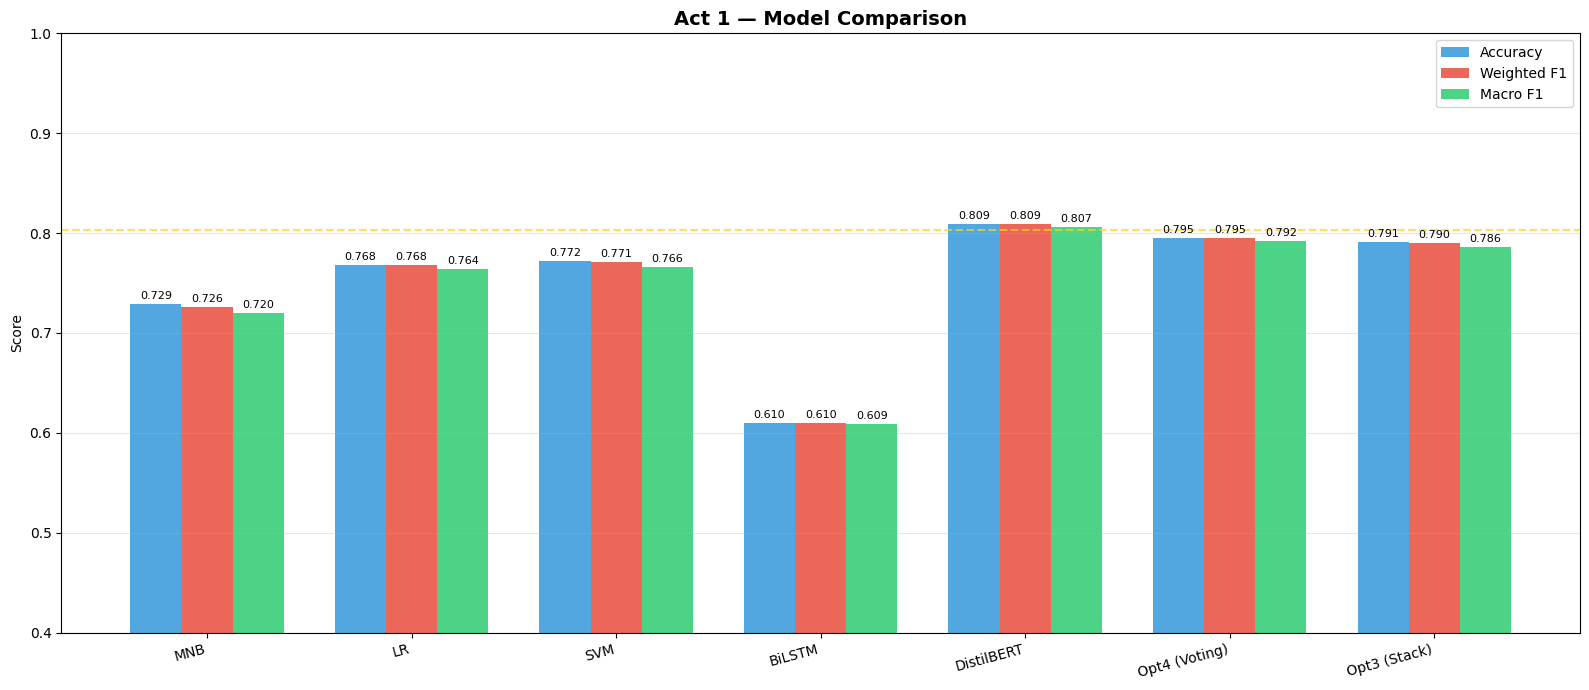

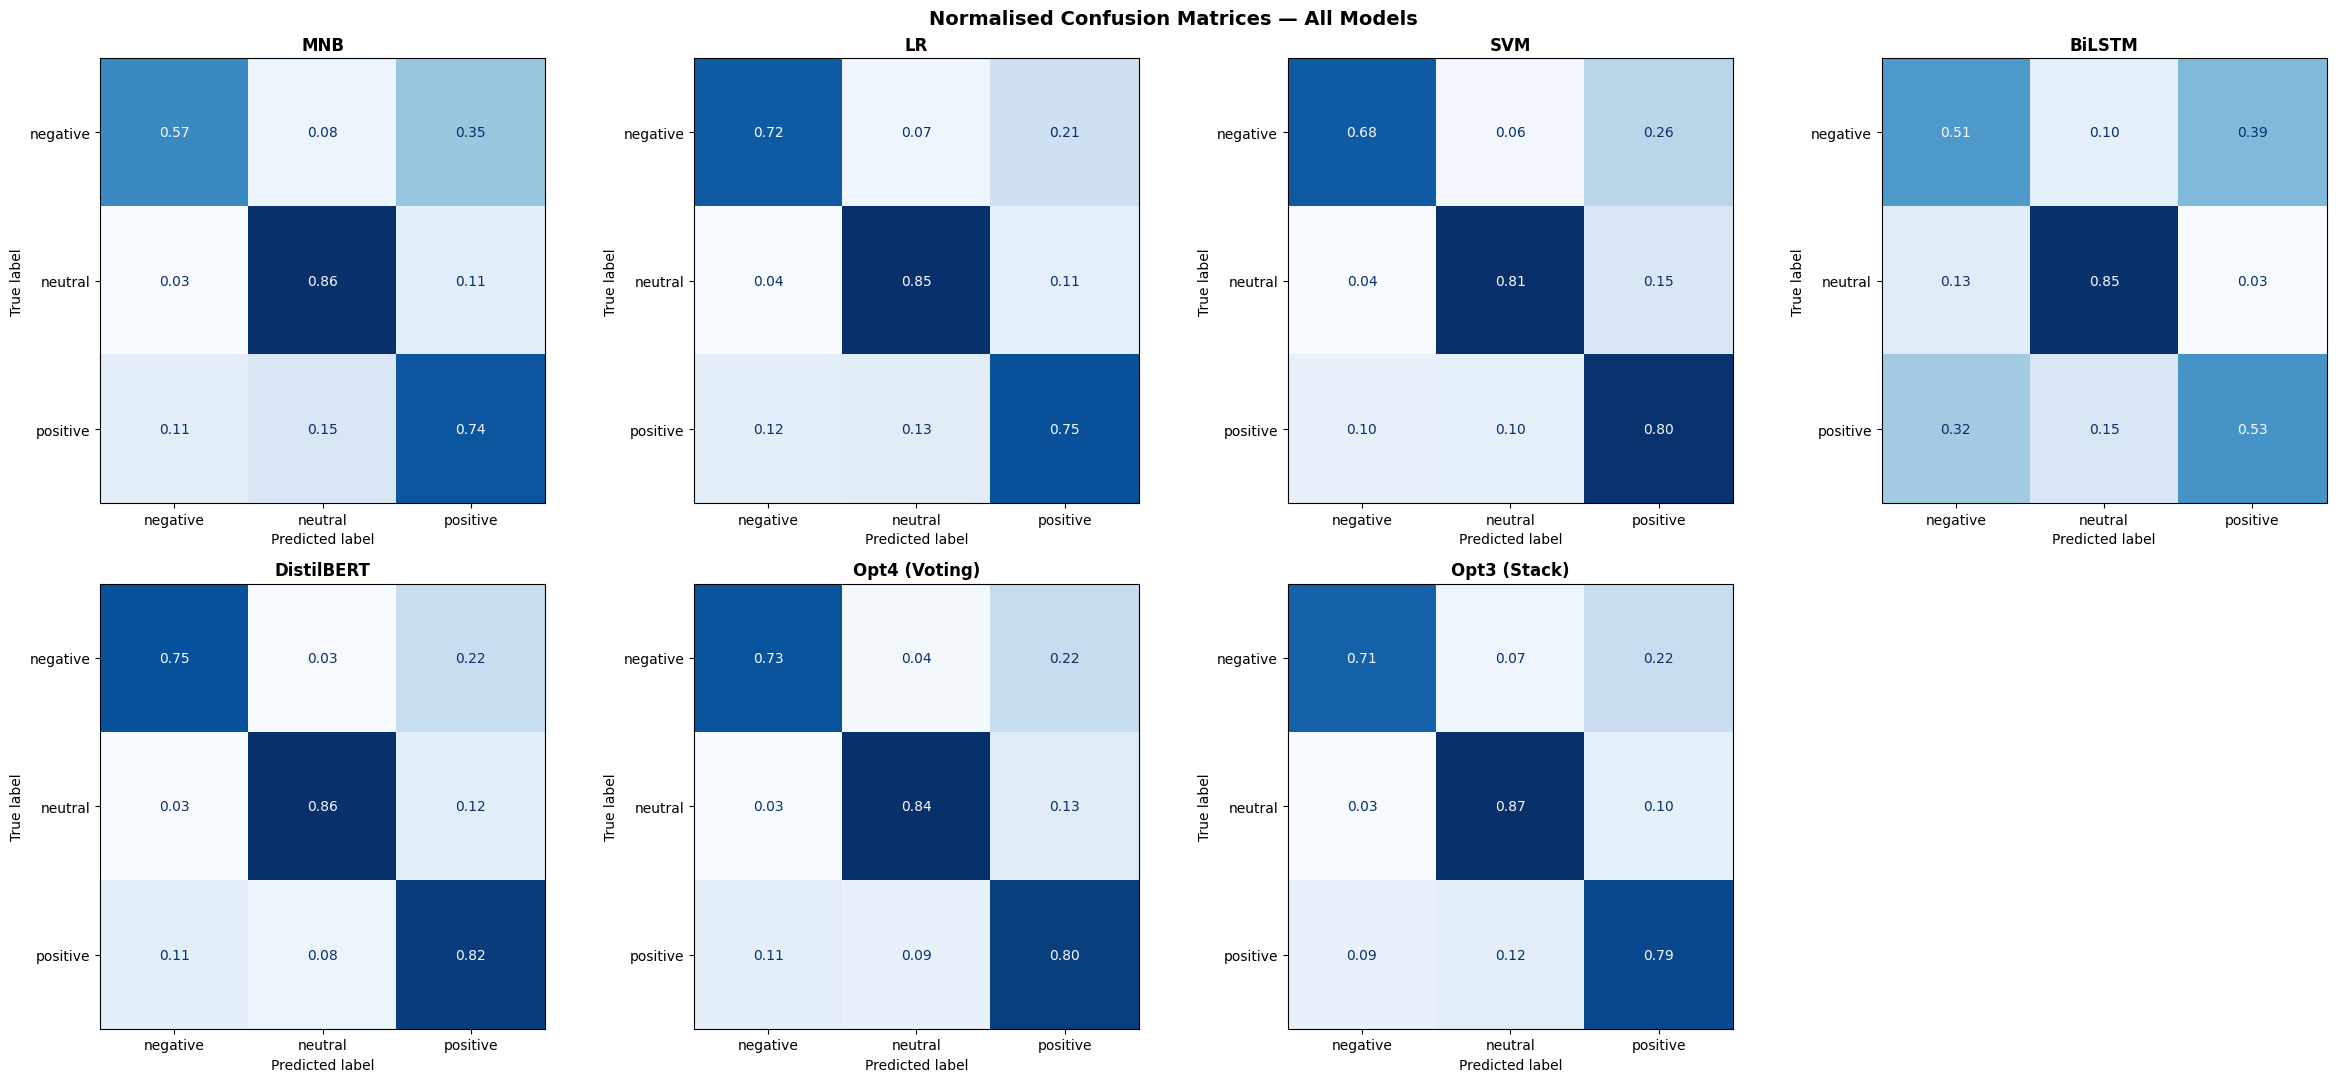

In [ ]:
# Section 9 — Final Act 1 Comparison Visualisation

# Fix — use correct key names matching what was stored
all_models = {
    'MNB'           : basic_results['MNB']['preds'],
    'LR'            : basic_results['LR']['preds'],
    'SVM'           : basic_results['SVM']['preds'],
    'BiLSTM'        : y_pred_bilstm_fixed,
    'DistilBERT'    : y_pred_distilbert_fixed,
    'Opt4 (Voting)' : y_pred_opt4,
    'Opt3 (Stack)'  : y_pred_opt3,
}

# Reprint summary table
print('='*65)
print(f'{"Model":<20} {"Accuracy":>10} {"Weighted F1":>12} {"Macro F1":>10}')
print('='*65)
for name, preds in all_models.items():
    acc = accuracy_score(y_test, preds)
    wf1 = f1_score(y_test, preds, average='weighted')
    mf1 = f1_score(y_test, preds, average='macro')
    print(f'{name:<20} {acc:>10.4f} {wf1:>12.4f} {mf1:>10.4f}')
print('='*65)

# ── Bar chart comparison ───────────────────────────────────────────────
metrics   = ['Accuracy', 'Weighted F1', 'Macro F1']
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']
names     = list(all_models.keys())
x         = np.arange(len(names))
width     = 0.25

fig, ax = plt.subplots(figsize=(16, 7))
for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    vals = []
    for preds in all_models.values():
        if metric == 'Accuracy':
            vals.append(accuracy_score(y_test, preds))
        elif metric == 'Weighted F1':
            vals.append(f1_score(y_test, preds, average='weighted'))
        else:
            vals.append(f1_score(y_test, preds, average='macro'))
    bars = ax.bar(x + i*width, vals, width, label=metric,
                  color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Score')
ax.set_title('Act 1 — Model Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(y=0.8028, color='gold', linestyle='--',
           alpha=0.7, label='DistilBERT baseline')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Confusion matrices ────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 4, figsize=(24, 11))
axes = axes.flatten()

for i, (name, preds) in enumerate(all_models.items()):
    cm   = confusion_matrix(y_test, preds, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], values_format='.2f', cmap='Blues', colorbar=False)
    axes[i].set_title(name, fontweight='bold')
    axes[i].grid(False)

axes[-1].set_visible(False)
plt.suptitle('Normalised Confusion Matrices — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Debug — check what predictions are actually stored
for name, results in basic_results.items():
    preds = results['preds']
    mf1   = f1_score(y_test, preds, average='macro')
    print(f'{name:<12} → stored mf1: {results["mf1"]:.4f} | recomputed: {mf1:.4f}')

# Also check shapes
print('\nPrediction array shapes:')
print(f'y_pred_bilstm   : {y_pred_bilstm.shape}, unique: {np.unique(y_pred_bilstm)}')
print(f'y_pred_distilbert: {y_pred_distilbert.shape}, unique: {np.unique(y_pred_distilbert)}')

# Check if they are identical
print(f'\nBiLSTM == DistilBERT predictions: {np.array_equal(y_pred_bilstm, y_pred_distilbert)}')

LR           → stored mf1: 0.7644 | recomputed: 0.7644
SVM          → stored mf1: 0.7657 | recomputed: 0.7657
MNB          → stored mf1: 0.7196 | recomputed: 0.7196
Bidirectional → stored mf1: 0.6093 | recomputed: 0.6093
DistilBERT   → stored mf1: 0.8066 | recomputed: 0.8066

Prediction array shapes:
y_pred_bilstm   : (2125,), unique: [0 1 2]
y_pred_distilbert: (2125,), unique: [0 1 2]

BiLSTM == DistilBERT predictions: False


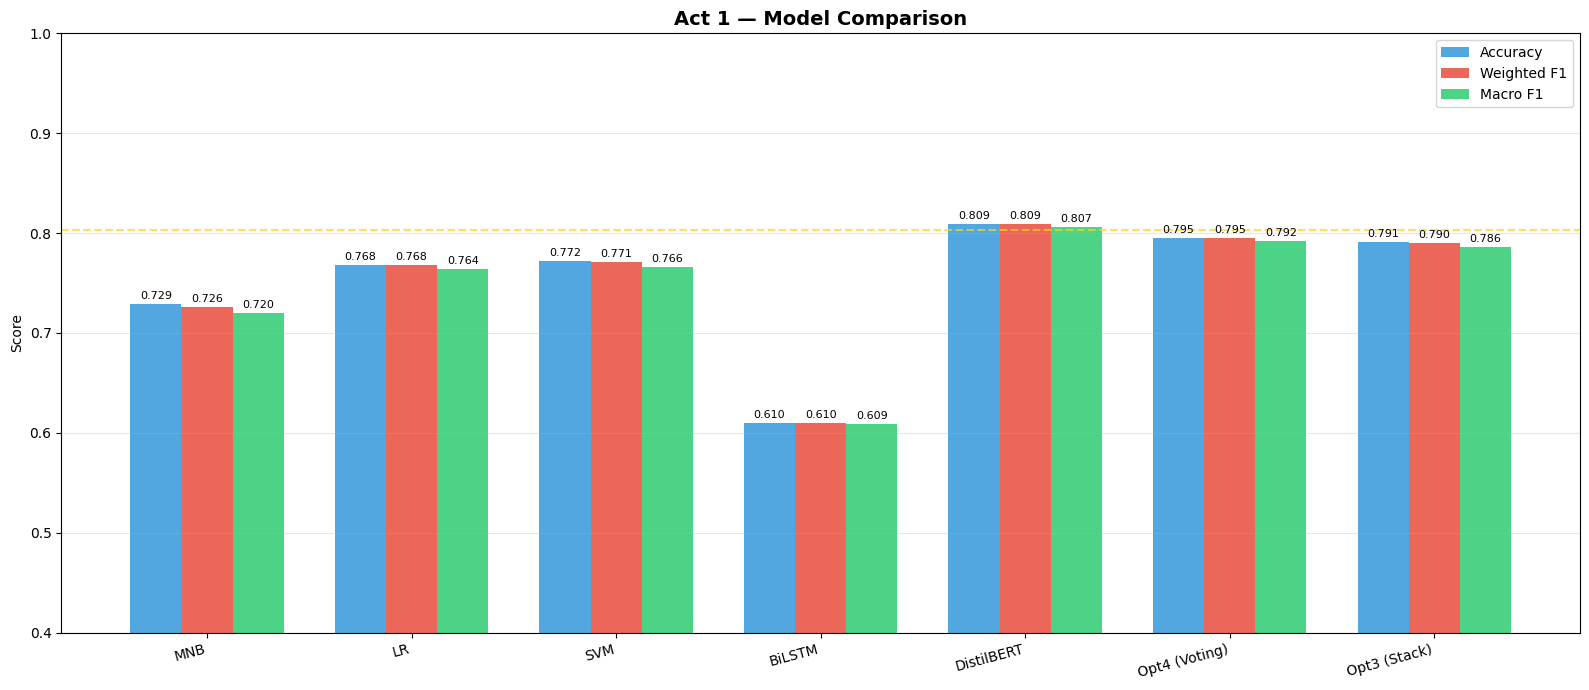

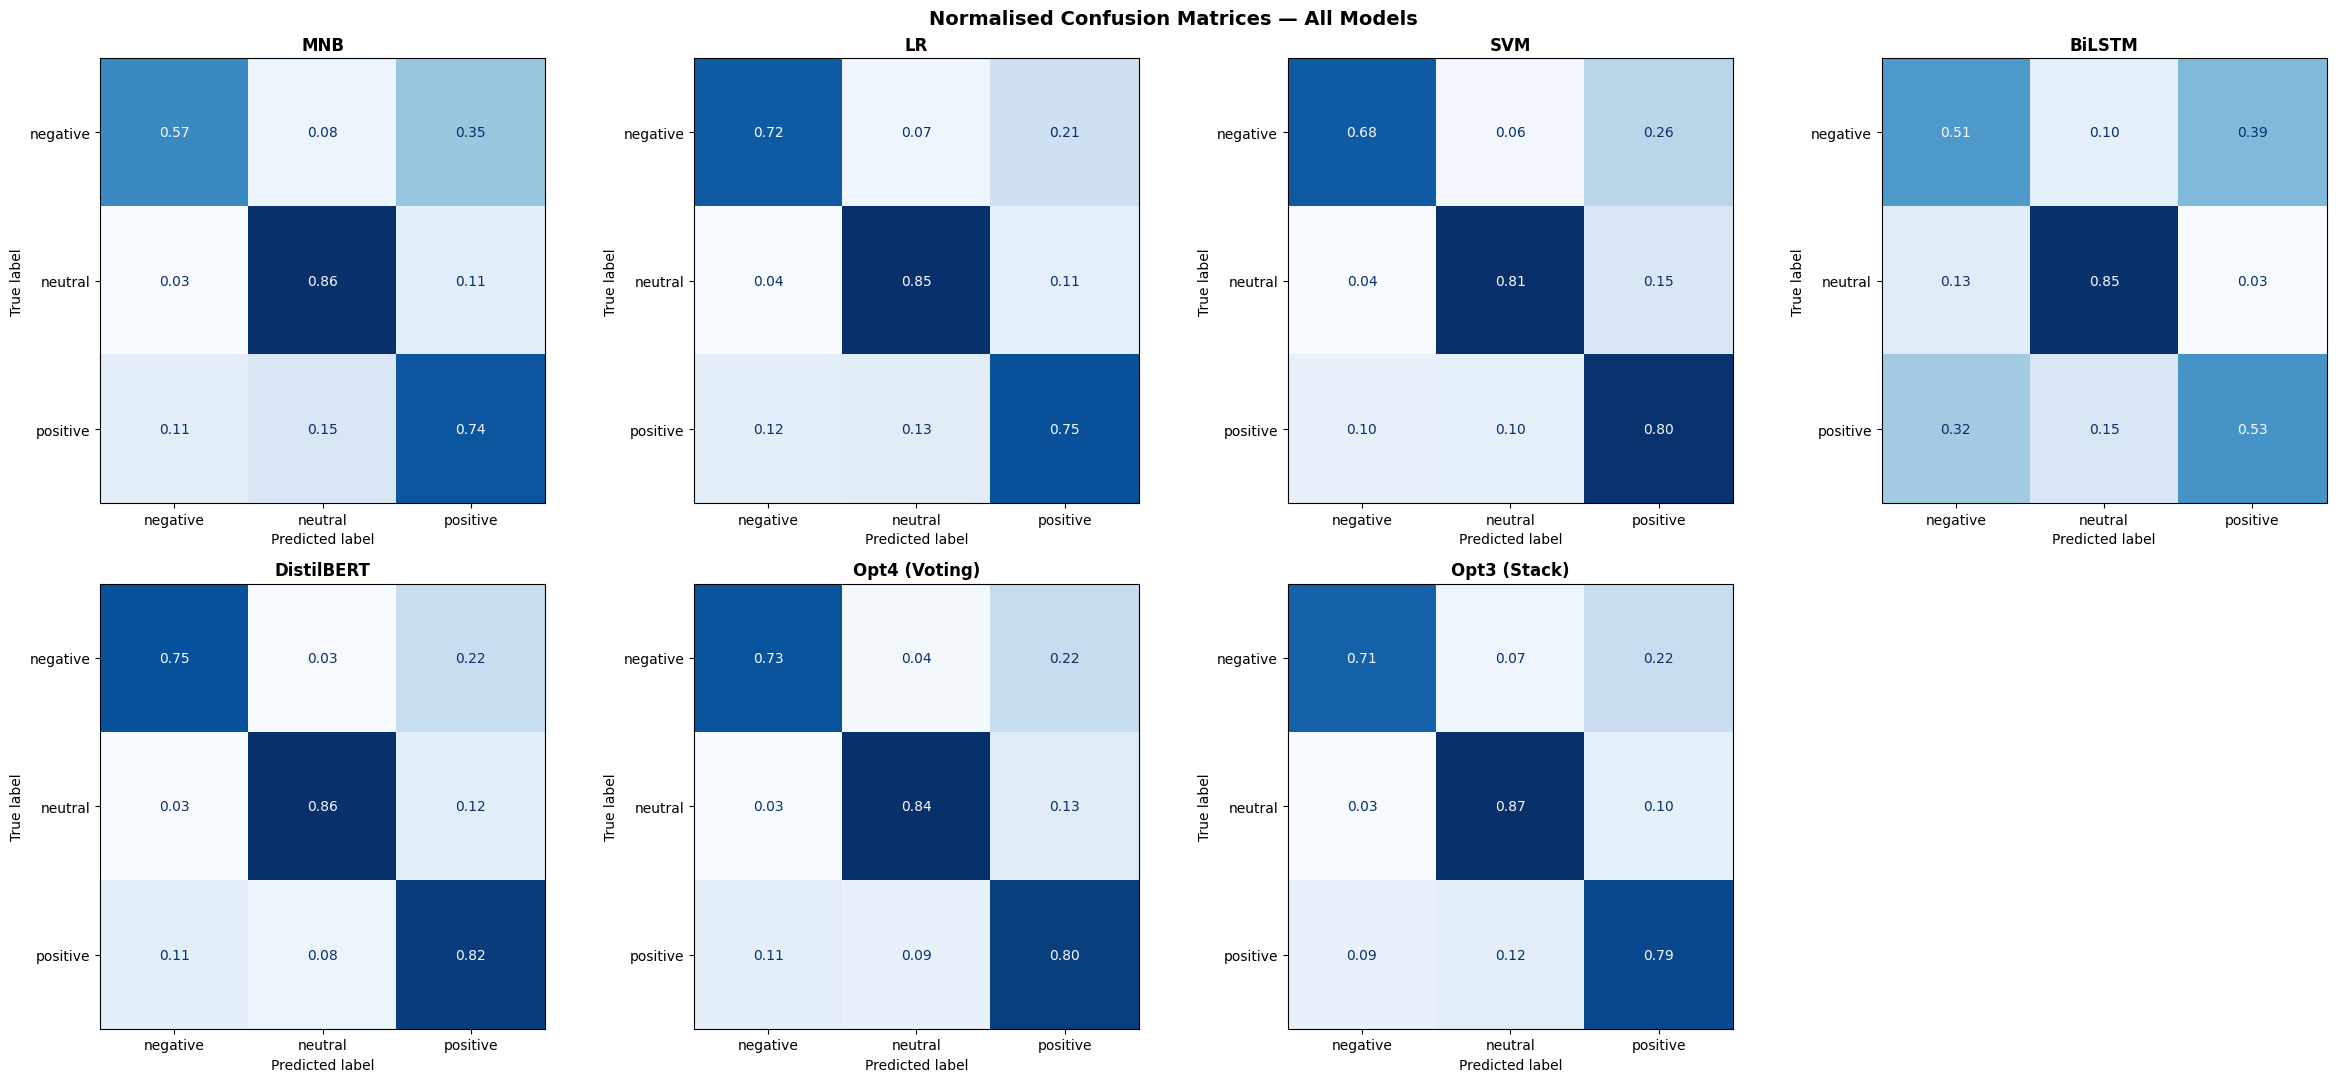

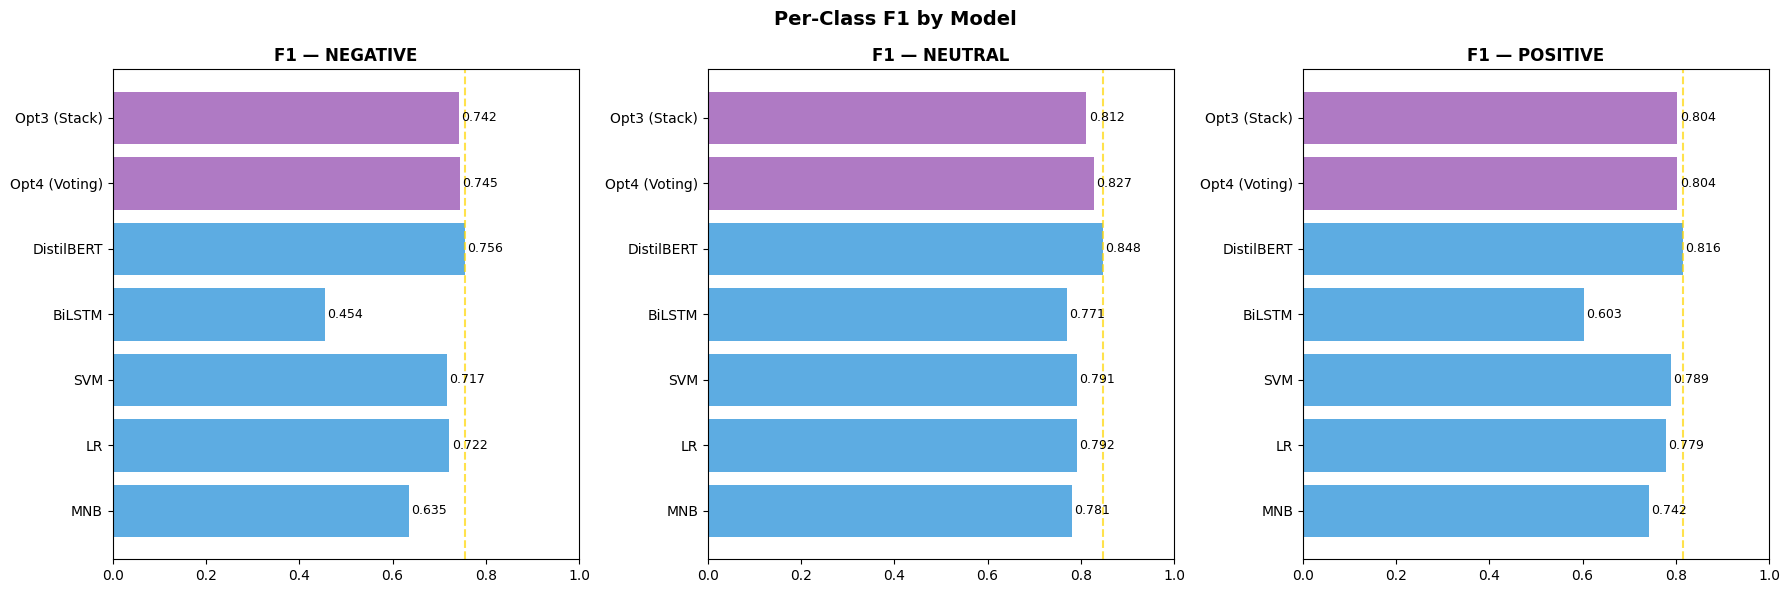

In [ ]:
# Act 1 visualisations

# ── Bar chart ─────────────────────────────────────────────────────────
metrics    = ['Accuracy', 'Weighted F1', 'Macro F1']
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']
names      = list(all_models.keys())
x          = np.arange(len(names))
width      = 0.25

fig, ax = plt.subplots(figsize=(16, 7))
for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    vals = []
    for preds in all_models.values():
        if metric == 'Accuracy':
            vals.append(accuracy_score(y_test, preds))
        elif metric == 'Weighted F1':
            vals.append(f1_score(y_test, preds, average='weighted'))
        else:
            vals.append(f1_score(y_test, preds, average='macro'))
    bars = ax.bar(x + i*width, vals, width, label=metric,
                  color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Score')
ax.set_title('Act 1 — Model Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(y=0.8028, color='gold', linestyle='--', alpha=0.7,
           label='DistilBERT (best)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Confusion matrices ────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 4, figsize=(24, 11))
axes = axes.flatten()

for i, (name, preds) in enumerate(all_models.items()):
    cm   = confusion_matrix(y_test, preds, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], values_format='.2f', cmap='Blues', colorbar=False)
    axes[i].set_title(name, fontweight='bold')
    axes[i].grid(False)

axes[-1].set_visible(False)
plt.suptitle('Normalised Confusion Matrices — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Per-class F1 comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cls_idx, cls_name in zip(axes, [0, 1, 2], le.classes_):
    f1_vals = [f1_score(y_test, preds, average=None)[cls_idx]
               for preds in all_models.values()]
    colors  = ['#9b59b6' if 'Opt' in n else '#3498db' for n in names]
    bars    = ax.barh(names, f1_vals, color=colors, alpha=0.8)
    for bar, val in zip(bars, f1_vals):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_xlim(0, 1.0)
    ax.set_title(f'F1 — {cls_name.upper()}', fontweight='bold')
    ax.axvline(x=max(f1_vals), color='gold', linestyle='--', alpha=0.7)

plt.suptitle('Per-Class F1 by Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

DistilBERT alone outperforms both ensembled architectures. Pre-trained contextual knowledge matters more than combining multiple weaker models on a small domain-specific dataset (10k samples). The BiLSTM trained from scratch couldn't compete

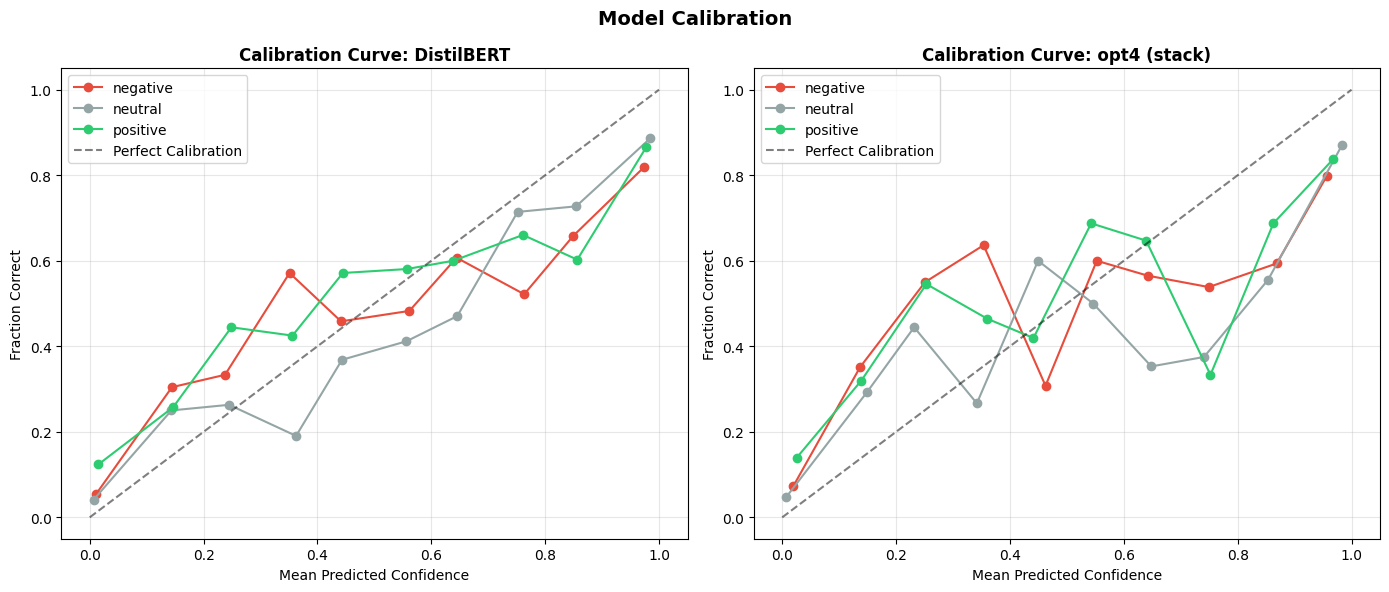

In [ ]:
# uncertainty quanification

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

for ax, name, probs in zip(
    axes,
    ["DistilBERT", "opt4 (stack)"],
    [prob_distilbert, meta_learner.predict_proba(meta_test)]
  ):
    for cls_idx, cls_name, colour, in zip([0, 1, 2], le.classes_, ['#E74C3C', '#95A5A6', '#2ECC71']):
      fraction_pos, mean_pred = calibration_curve(
          (y_test == cls_idx).astype(int),
          probs[:, cls_idx],
          n_bins = 10
      )
      ax.plot(mean_pred, fraction_pos, marker = 'o', label = cls_name, color = colour)

    ax.plot([0, 1], [0, 1], "k--", alpha = 0.5, label = "Perfect Calibration")
    ax.set_title(f"Calibration Curve: {name}", fontweight = 'bold')
    ax.set_xlabel("Mean Predicted Confidence")
    ax.set_ylabel("Fraction Correct")
    ax.legend()
    ax.grid(alpha = 0.3)

plt.suptitle("Model Calibration", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

Both models are overconfident in the mid-range

At high confidence both models shows improvements

In [ ]:
# Expected Calibration Error

def compute_ece(y_true, probs, n_bins = 10):
  ece = 0.0
  bin_edges = np.linspace(0, 1, n_bins + 1)
  max_probs = probs.max(axis = 1)
  preds = probs.argmax(axis = 1)
  correct = (preds == y_true).astype(float)

  for i in range(n_bins):
    in_bin = (max_probs >- bin_edges[i]) & (max_probs < bin_edges[i+1])
    if in_bin.sum() == 0:
      continue
    bin_acc = correct[in_bin].mean()
    bin_conf = max_probs[in_bin].mean()
    bin_weight = in_bin.sum() / len(y_true)
    ece += bin_weight * abs(bin_acc - bin_conf)

  return ece

ece_distilbert = compute_ece(y_test, prob_distilbert)
ece_opt3 = compute_ece(y_test, prob_opt3)
ece_opt4 = compute_ece(y_test, meta_learner.predict_proba(meta_test))

print("Expected Calibration Error:")
print(f"\tDistilBert\t:\t{ece_distilbert:.4f}")
print(f"\tOpt3 (voting)\t:\t{ece_opt3:.4f}")
print(f"\tOpt4 (stack)\t:\t{ece_opt4:.4f}")

Expected Calibration Error:
	DistilBert	:	0.1689
	Opt3 (voting)	:	0.0275
	Opt4 (stack)	:	0.1845


opt3 (stack) is extremely well calibrated, providing an interesting trade off between accuracy and calibration

DistilBERT is more accurate but overconfident
meta-learner is less accurate overall but its confidence scores are far more trustworthy

In a trading context: Calibration may matter more than raw accuracy?

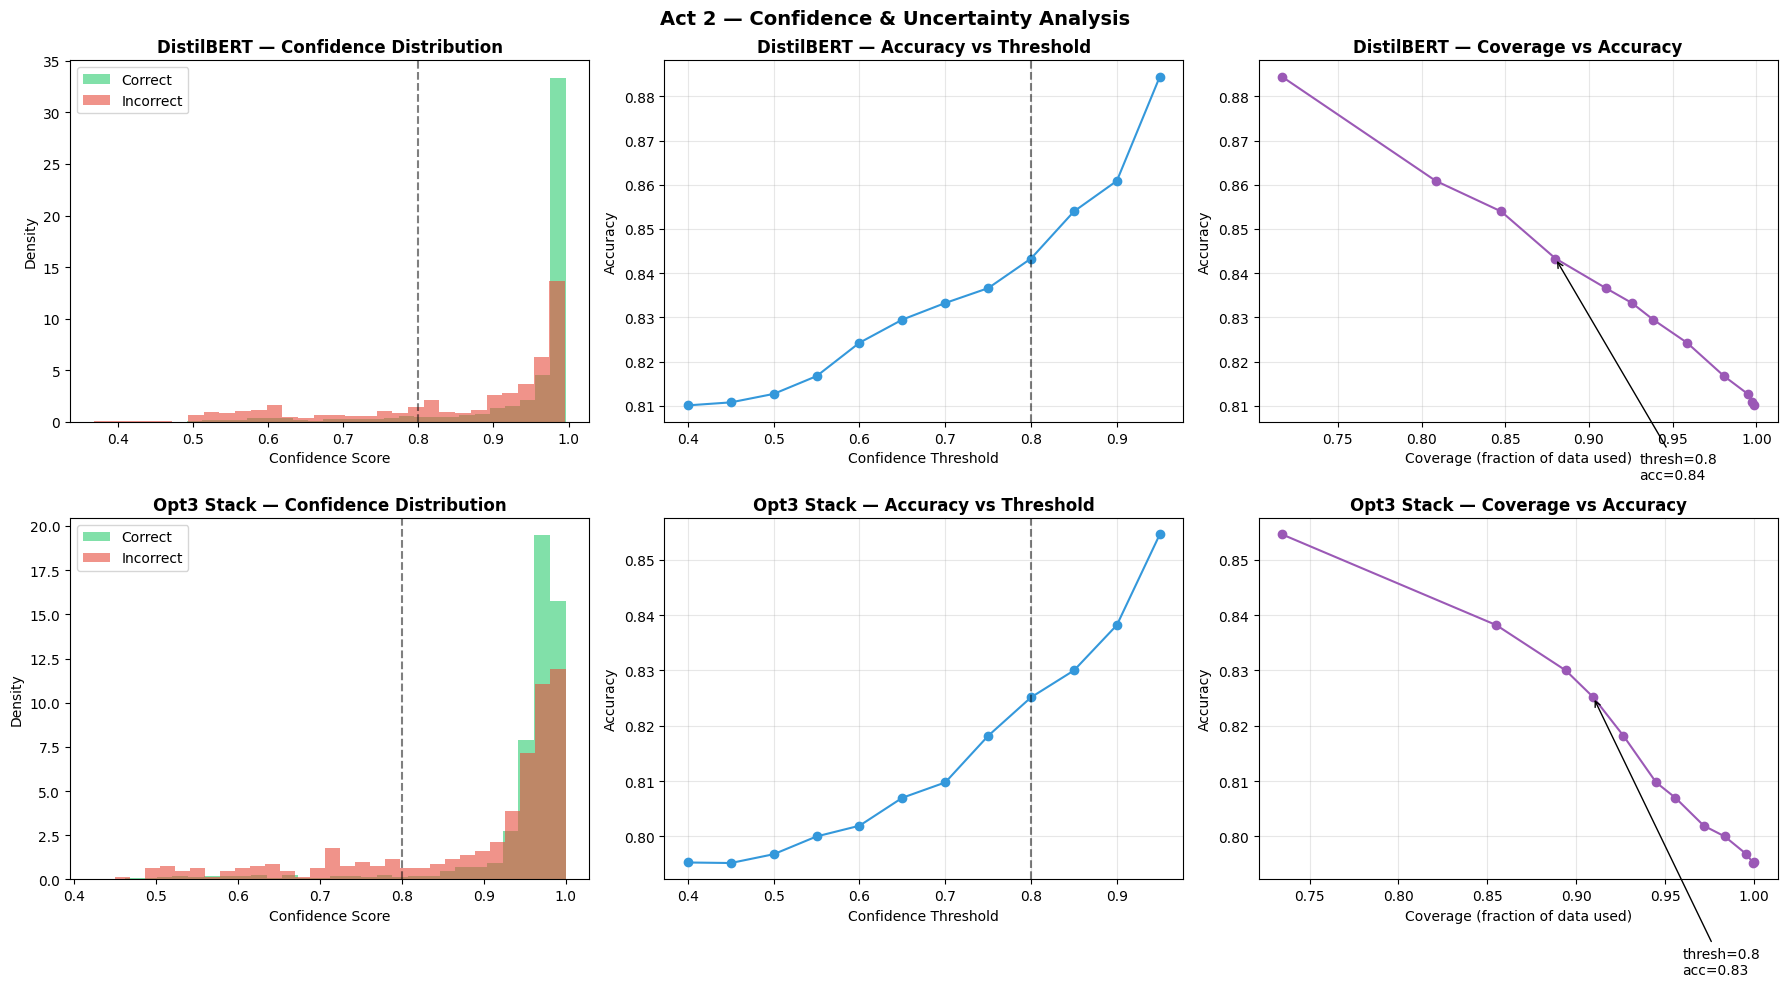

At 0.80 confidence threshold:
  DistilBERT      → Accuracy: 0.8433 | Coverage: 88.00% (1870 samples)
  Opt3 Stack      → Accuracy: 0.8251 | Coverage: 90.96% (1933 samples)


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (name, probs) in enumerate([
    ('DistilBERT', prob_distilbert),
    ('Opt3 Stack', meta_learner.predict_proba(meta_test))
]):
    preds      = probs.argmax(axis=1)
    confidence = probs.max(axis=1)   # max probability = model confidence
    correct    = preds == y_test

    # ── Plot 1: Confidence distribution (correct vs incorrect) ────────
    axes[row, 0].hist(confidence[correct],  bins=30, alpha=0.6,
                      color='#2ecc71', label='Correct', density=True)
    axes[row, 0].hist(confidence[~correct], bins=30, alpha=0.6,
                      color='#e74c3c', label='Incorrect', density=True)
    axes[row, 0].set_title(f'{name} — Confidence Distribution',
                            fontweight='bold')
    axes[row, 0].set_xlabel('Confidence Score')
    axes[row, 0].set_ylabel('Density')
    axes[row, 0].legend()
    axes[row, 0].axvline(x=0.8, color='black', linestyle='--',
                          alpha=0.5, label='0.8 threshold')

    # ── Plot 2: Accuracy at each confidence threshold ─────────────────
    # Shows how accuracy improves as we raise the confidence threshold
    thresholds = np.arange(0.4, 0.99, 0.05)
    accs, coverages = [], []
    for thresh in thresholds:
        mask = confidence >= thresh
        if mask.sum() < 10:  # skip if too few samples
            break
        accs.append(accuracy_score(y_test[mask], preds[mask]))
        coverages.append(mask.mean())  # fraction of data we'd still act on

    axes[row, 1].plot(thresholds[:len(accs)], accs,
                      color='#3498db', marker='o', label='Accuracy')
    axes[row, 1].set_title(f'{name} — Accuracy vs Threshold',
                            fontweight='bold')
    axes[row, 1].set_xlabel('Confidence Threshold')
    axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].axvline(x=0.8, color='black', linestyle='--', alpha=0.5)
    axes[row, 1].grid(alpha=0.3)

    # ── Plot 3: Coverage vs Accuracy trade-off ────────────────────────
    # Coverage = fraction of predictions we act on
    # As threshold rises, coverage drops but accuracy rises
    axes[row, 2].plot(coverages, accs, color='#9b59b6', marker='o')
    axes[row, 2].set_title(f'{name} — Coverage vs Accuracy',
                            fontweight='bold')
    axes[row, 2].set_xlabel('Coverage (fraction of data used)')
    axes[row, 2].set_ylabel('Accuracy')
    axes[row, 2].grid(alpha=0.3)
    # Annotate the 0.8 threshold point
    if len(accs) > 0:
        idx = min(range(len(thresholds[:len(accs)])),
                  key=lambda i: abs(thresholds[i] - 0.8))
        axes[row, 2].annotate(f'thresh=0.8\nacc={accs[idx]:.2f}',
                               xy=(coverages[idx], accs[idx]),
                               xytext=(coverages[idx]+0.05, accs[idx]-0.05),
                               arrowprops=dict(arrowstyle='->'))

plt.suptitle('Act 2 — Confidence & Uncertainty Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print key numbers at 0.8 threshold
print('At 0.80 confidence threshold:')
for name, probs in [('DistilBERT', prob_distilbert),
                    ('Opt3 Stack', meta_learner.predict_proba(meta_test))]:
    preds      = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    mask       = confidence >= 0.8
    acc        = accuracy_score(y_test[mask], preds[mask])
    coverage   = mask.mean()
    print(f'  {name:<15} → Accuracy: {acc:.4f} | '
          f'Coverage: {coverage:.2%} ({mask.sum()} samples)')

Filtering by confidence improves accuracy for both models. At the 0.80 threshold, DistilBERT still leads on accuracy but Opt3 ECE of 0.016 means its confidence scores are more trustworthy

In [ ]:
TICKERS = ['AAPL', 'TSLA', 'NVDA', 'MSFT']

print("Fetching price data:")
price_data = {}

for ticker in TICKERS:
  stock = yf.Ticker(ticker)
  hist = stock.history(period = '3mo')

  hist['next_day_return'] = hist['Close'].pct_change().shift(-1)

  price_data[ticker] = hist
  print(f"\t{ticker}: {len(hist)} trading days\t|\tLatest Close: ${hist['Close'].iloc[-1]:.2f}")


Fetching price data:
	AAPL: 64 trading days	|	Latest Close: $299.24
	TSLA: 64 trading days	|	Latest Close: $404.66
	NVDA: 64 trading days	|	Latest Close: $207.41
	MSFT: 64 trading days	|	Latest Close: $393.83


In [ ]:
SAVE_DIR = '/content/drive/MyDrive/NLPQ/checkpoints/'
os.makedirs(SAVE_DIR, exist_ok = True)

print('saving checkpoints to Google Drive NLPQ folder')

# Basic model
joblib.dump(vectorizer, SAVE_DIR + 'tfidf_vectorizer.pk1')
joblib.dump(model_lr, SAVE_DIR + 'model_lr.pk1')
joblib.dump(model_svm, SAVE_DIR + 'model_svm.pk1')
joblib.dump(model_mnb, SAVE_DIR + 'model_mnb.pk1')
joblib.dump(meta_learner, SAVE_DIR + 'meta_learner.pk1')
joblib.dump(le, SAVE_DIR + 'label_encoder.pk1')
print('Basic Models saved')

# BiLSTM
model_bilstm.save(SAVE_DIR + 'bilstm_model.keras')
joblib.dump(keras_tokenizer, SAVE_DIR + 'keras_tokenizer.pk1')
print('BiLSTM + Keras saved')

# DistilBERT
model_distilbert.save_pretrained(SAVE_DIR + 'distilbert_model')
bert_tokenizer.save_pretrained(SAVE_DIR + 'distilbert_findtuned')
print('DistilBERT saved')

# Probability arrays
np.save(SAVE_DIR + 'prob_distilbert.npy', prob_distilbert)
np.save(SAVE_DIR + 'prob_bilstm.npy', prob_bilstm)
np.save(SAVE_DIR + 'y_test.npy', y_test)
np.save(SAVE_DIR + 'y_train.npy', y_train)
print('Probability arrays saved')

# Text arary
joblib.dump(X_text_train.tolist(), SAVE_DIR + 'X_text_train.pk1')
joblib.dump(X_text_test.tolist(), SAVE_DIR + 'X_text_test.pk1')
print('Text arrays saved')

print()
print('All checkpoints saved!')
for f in sorted(os.listdir(SAVE_DIR)):
  size_kb = os.path.getsize(SAVE_DIR + f) / 1024
  print(f'  {f:<45} {size_kb:>8.1f} KB')

saving checkpoints to Google Drive NLPQ folder
Basic Models saved
BiLSTM + Keras saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT saved
Probability arrays saved
Text arrays saved

All checkpoints saved!
  X_text_test.pk1                                  154.0 KB
  X_text_train.pk1                                 604.7 KB
  bilstm_model.keras                              3719.3 KB
  distilbert_findtuned                               4.0 KB
  distilbert_model                                   4.0 KB
  keras_tokenizer.pk1                              504.3 KB
  label_encoder.pk1                                  0.5 KB
  meta_learner.pk1                                   1.2 KB
  model_lr.pk1                                     300.9 KB
  model_mnb.pk1                                    600.4 KB
  model_svm.pk1                                    301.4 KB
  prob_bilstm.npy                                   25.0 KB
  prob_distilbert.npy                               25.0 KB
  tfidf_vectorizer.pk1                             498.7 KB
  y_test.npy                                        16.7 KB
  y_train.npy   

In [ ]:
import os
for folder in ['distilbert_findtuned', 'distilbert_model']:
    path = SAVE_DIR + folder
    if os.path.exists(path):
        print(f'{folder}:')
        for f in os.listdir(path):
            size_kb = os.path.getsize(os.path.join(path, f)) / 1024
            print(f'    {f:<30} {size_kb:>10.1f} KB')
    else:
        print(f'{folder}: does not exist')

distilbert_findtuned:
    tokenizer_config.json                 0.3 KB
    tokenizer.json                      695.0 KB
distilbert_model:
    config.json                           0.8 KB
    model.safetensors                261558.2 KB


In [ ]:
import shutil

# copy tokenizer files into the folder that has the model weights
for f in os.listdir(SAVE_DIR + 'distilbert_findtuned'):
    shutil.copy(
        SAVE_DIR + 'distilbert_findtuned/' + f,
        SAVE_DIR + 'distilbert_model/' + f
    )

print('Merged. Contents of distilbert_model:')
for f in os.listdir(SAVE_DIR + 'distilbert_model'):
    size_kb = os.path.getsize(SAVE_DIR + 'distilbert_model/' + f) / 1024
    print(f'    {f:<30} {size_kb:>10.1f} KB')

Merged. Contents of distilbert_model:
    config.json                           0.8 KB
    model.safetensors                261558.2 KB
    tokenizer_config.json                 0.3 KB
    tokenizer.json                      695.0 KB


**ACT 3**

In [ ]:
def fetch_headlines(ticker, max_items = 30):
  query = quote(f"{ticker} stock")
  url = f"https://news.google.com/rss/search?q={query}&hl=en=US&gl=US&ceid=US:en"
  feed = feedparser.parse(url)

  headlines = []
  for entry in feed.entries[:max_items]:
    headlines.append({
        'ticker': ticker,
        'title': entry.title,
        'published': entry.published,
        'link': entry.link
    })

  return headlines

print("Fetching headlines through Google News RSS\n")
# all_headlines is a dictionary and not a list, already exist in the file
all_headlines = {}

for ticker in TICKERS:
  headlines = fetch_headlines(ticker)
  all_headlines[ticker] = headlines
  print(f"\t{ticker}: {len(headlines)} headlines fetched")

print("\nSample Headline:")
for ticker in TICKERS:
  print(f"\n{ticker}:")
  for h in all_headlines[ticker][:3]:
    print(f"\t-\t{h['title']}\t\t\t({h['published']})")

Fetching headlines through Google News RSS

	AAPL: 30 headlines fetched
	TSLA: 30 headlines fetched
	NVDA: 30 headlines fetched
	MSFT: 30 headlines fetched

Sample Headline:

AAPL:
	-	Apple (AAPL) Stock Could Be Pricing In Too Much Growth After A 50% Run - Yahoo Finance			(Tue, 16 Jun 2026 12:08:36 GMT)
	-	Apple Stock Is Down After WWDC. There’s More to Its AI Strategy Than Meets the Eye. - Barron's			(Tue, 16 Jun 2026 14:24:00 GMT)
	-	AAPL Stock Gains — Apple Reportedly Eyes Foldable iPhone, Camera-Equipped AirPods Launches In 2027 - Stocktwits			(Tue, 16 Jun 2026 23:40:41 GMT)

TSLA:
	-	Cathie Wood Dumps Millions Worth Of Tesla, Palantir, Roku, AMD And More Even As TSLA Stock Pops On SpaceX - Benzinga			(Tue, 16 Jun 2026 03:28:43 GMT)
	-	NIO & TSLA See Fresh Tailwinds But Only One Stock Is Worth Owning - Yahoo Finance			(Mon, 15 Jun 2026 14:17:00 GMT)
	-	Tesla Stock Can’t Escape SpaceX’s Gravity - Barron's			(Tue, 16 Jun 2026 20:26:00 GMT)

NVDA:
	-	Nvidia Stock: How the Chip Maker I

In [ ]:
def parse_pubdate(pubdate_str):
  # Google News RSS format
  return pd.to_datetime(pubdate_str).tz_localize(None).date()

def match_to_trading_date(headline_date, trading_date):
  # finds the nearest trading date on or after the headline date
  headline_date = pd.Timestamp(headline_date)
  future_date = trading_date[trading_date >= headline_date]
  if len(future_date) == 0:
    return None
  return future_date[0]

matched_headline = {ticker: [] for ticker in TICKERS}

for ticker in TICKERS:
  trading_date = pd.to_datetime(price_data[ticker].index.date)
  trading_date = pd.Series(trading_date).sort_values().unique()
  trading_date = pd.to_datetime(trading_date)

  for h in all_headlines[ticker]:
    pub_date = parse_pubdate(h['published'])
    matched_date = match_to_trading_date(pub_date, trading_date)

    if matched_date is not None:
      matched_headline[ticker].append({
       'ticker': ticker,
       'title': h['title'],
       'published_date': pub_date,
       'trading_date': matched_date,
       'link': h['link']
      })

print("Headlines matched to trading dates:\n")
for ticker in TICKERS:
  print(f"\t\t{ticker}: {len(matched_headline[ticker])} / {len(all_headlines[ticker])} matched")


print("\nSample Matches:\n")
for ticker in TICKERS:
  print(f"\n{ticker}:")
  for h in matched_headline[ticker][:3]:
    print(f"\t-\t{h['title']}\t\t\t({h['published_date']} → {h['trading_date']})")

Headlines matched to trading dates:

		AAPL: 30 / 30 matched
		TSLA: 28 / 30 matched
		NVDA: 29 / 30 matched
		MSFT: 29 / 30 matched

Sample Matches:


AAPL:
	-	Apple (AAPL) Stock Could Be Pricing In Too Much Growth After A 50% Run - Yahoo Finance			(2026-06-16 → 2026-06-16 00:00:00)
	-	Apple Stock Is Down After WWDC. There’s More to Its AI Strategy Than Meets the Eye. - Barron's			(2026-06-16 → 2026-06-16 00:00:00)
	-	AAPL Stock Gains — Apple Reportedly Eyes Foldable iPhone, Camera-Equipped AirPods Launches In 2027 - Stocktwits			(2026-06-16 → 2026-06-16 00:00:00)

TSLA:
	-	Cathie Wood Dumps Millions Worth Of Tesla, Palantir, Roku, AMD And More Even As TSLA Stock Pops On SpaceX - Benzinga			(2026-06-16 → 2026-06-16 00:00:00)
	-	NIO & TSLA See Fresh Tailwinds But Only One Stock Is Worth Owning - Yahoo Finance			(2026-06-15 → 2026-06-15 00:00:00)
	-	Tesla Stock Can’t Escape SpaceX’s Gravity - Barron's			(2026-06-16 → 2026-06-16 00:00:00)

NVDA:
	-	Nvidia Stock: How the Chip Maker Is Tra

In [ ]:
def predict_distilbert(texts, batch_size = 16):
  model_distilbert.eval()
  all_probs = []

  for i in range(0, len(texts), batch_size):
    batch = texts[i:i + batch_size]
    inputs = bert_tokenizer(
        batch, truncation = True, padding = "max_length", max_length = 123, return_tensors = 'pt'
    ).to(device)

    with torch.no_grad():
      logits = model_distilbert(**inputs).logits
      probs = torch.softmax(logits, dim = 1).cpu().numpy()
    all_probs.append(probs)

  return np.vstack(all_probs)

def predict_opt3(texts):
  texts_clean = [preprocess_finance(t) for t in texts]

  X_tfidf = vectorizer.transform(texts_clean)
  X_pos = np.array([extract_pos_features(t) for t in texts_clean])
  X_lm = np.array([extract_lm_features(t) for t in texts_clean])

  from scipy.sparse import hstack, csr_matrix
  X_combined = hstack([X_tfidf, csr_matrix(X_pos), csr_matrix(X_lm)])

  prob_lr = model_lr.predict_proba(X_combined)
  prob_svm = model_svm.predict_proba(X_combined)
  prob_mnb = model_mnb.predict_proba(X_tfidf)

  seqs = keras_tokenizer.texts_to_sequences(texts_clean)
  seqs_padded = pad_sequences(seqs, maxlen = 100, padding = 'post', truncating = 'post')
  prob_bilstm = model_bilstm.predict(seqs_padded, verbose = 0)

  prob_bert = predict_distilbert(texts)

  meta_features = np.hstack([prob_lr, prob_svm, prob_mnb, prob_bilstm, prob_bert])
  prob_opt3 = meta_learner.predict_proba(meta_features)

  return prob_opt3

print("Running headlines through DistilBERT and Opt3:\n")

for ticker in TICKERS:
  texts = [h['title'] for h in matched_headline[ticker]]

  prob_bert = predict_distilbert(texts)
  prob_opt3 = predict_opt3(texts)

  for i, h in enumerate(matched_headline[ticker]):
    h['bert_sentiment'] = le.classes_[prob_bert[i].argmax()]
    h['bert_confidence'] = float(prob_bert[i].max())
    h['opt3_sentiment'] = le.classes_[prob_opt3[i].argmax()]
    h['opt3_confidence'] = float(prob_opt3[i].max())

  print(f"\t\t{ticker}: {len(texts)} headlines scored")

print("\nSample scored Headlines:")
for ticker in TICKERS:
  print(f"\n{ticker}:")
  for h in matched_headline[ticker][:3]:
    print(f"\t\t\t{h['title'][:60]}")
    print(f"\t\t\tBERT: {h['bert_sentiment']:<8} ({h['bert_confidence']:.3f})   |  "
          f"Opt3: {h['opt3_sentiment']:<8} ({h['opt3_confidence']:.3f})")


Running headlines through DistilBERT and Opt3:

		AAPL: 30 headlines scored
		TSLA: 28 headlines scored
		NVDA: 29 headlines scored
		MSFT: 29 headlines scored

Sample scored Headlines:

AAPL:
			Apple (AAPL) Stock Could Be Pricing In Too Much Growth After
			BERT: negative (0.959)   |  Opt3: negative (0.986)
			Apple Stock Is Down After WWDC. There’s More to Its AI Strat
			BERT: negative (0.632)   |  Opt3: negative (0.836)
			AAPL Stock Gains — Apple Reportedly Eyes Foldable iPhone, Ca
			BERT: positive (0.993)   |  Opt3: positive (0.972)

TSLA:
			Cathie Wood Dumps Millions Worth Of Tesla, Palantir, Roku, A
			BERT: negative (0.969)   |  Opt3: negative (0.989)
			NIO & TSLA See Fresh Tailwinds But Only One Stock Is Worth O
			BERT: positive (0.990)   |  Opt3: positive (0.982)
			Tesla Stock Can’t Escape SpaceX’s Gravity - Barron's
			BERT: negative (0.827)   |  Opt3: negative (0.972)

NVDA:
			Nvidia Stock: How the Chip Maker Is Trading Today - Barron's
			BERT: positive (0.953)   |

In [ ]:
CONFIDENCE_THRESHOLD = 0.80

def apply_confidence_filter(headlines, model_key):
  # model_key: 'bert' or 'opt3'
  filtered = []
  for h in headlines:
    conf = h[f'{model_key}_confidence']
    if conf >= CONFIDENCE_THRESHOLD:
      filtered.append(h)
  return filtered

filtered_bert = {}
filtered_opt3 = {}

print(f"Applying confidence threshold (threshold = {CONFIDENCE_THRESHOLD})")

for ticker in TICKERS:
  filtered_bert[ticker] = apply_confidence_filter(matched_headline[ticker], 'bert')
  filtered_opt3[ticker] = apply_confidence_filter(matched_headline[ticker], 'opt3')

  print(f"\t\t{ticker}:")
  print(f"\t\tBERT signal retained: {len(filtered_bert[ticker])} / {len(matched_headline[ticker])}")
  print(f"\t\tOpt3 signal retained: {len(filtered_opt3[ticker])} / {len(matched_headline[ticker])}")

print("\nSignals that passed the filter (BERT):")
for ticker in TICKERS:
  print(f"\n{ticker}:")
  for h in filtered_bert[ticker][:5]:
    print(f"\t\t\t[{h['trading_date'].date()}] {h['bert_sentiment']:<8} ({h['bert_confidence']:.3f}) - {h['title'][:50]}")

Applying confidence threshold (threshold = 0.8)
		AAPL:
		BERT signal retained: 25 / 30
		Opt3 signal retained: 28 / 30
		TSLA:
		BERT signal retained: 23 / 28
		Opt3 signal retained: 25 / 28
		NVDA:
		BERT signal retained: 25 / 29
		Opt3 signal retained: 28 / 29
		MSFT:
		BERT signal retained: 28 / 29
		Opt3 signal retained: 28 / 29

Signals that passed the filter (BERT):

AAPL:
			[2026-06-16] negative (0.959) - Apple (AAPL) Stock Could Be Pricing In Too Much Gr
			[2026-06-16] positive (0.993) - AAPL Stock Gains — Apple Reportedly Eyes Foldable 
			[2026-06-15] positive (0.876) - Apple Stock Analysis: Buy or Sell After WWDC? - Th
			[2026-06-15] positive (0.990) - Can Apple Stock Reach $400 by 2028? Wall Street Sa
			[2026-06-11] positive (0.982) - Does Apple Stock Have More Upside? - Trefis

TSLA:
			[2026-06-16] negative (0.969) - Cathie Wood Dumps Millions Worth Of Tesla, Palanti
			[2026-06-15] positive (0.990) - NIO & TSLA See Fresh Tailwinds But Only One Stock 
			[2026-06-16]

In [ ]:
def parse_published_datetime(pubdate_str):
  return pd.to_datetime(pubdate_str, utc = True).tz_convert(None)

def aggregate_daily_signals(filtered_headlines, model_key):
  daily = {}
  for h in filtered_headlines:
    date = h['trading_date']
    pub_dt = parse_published_datetime(h['published_date']) # Fixed: Changed 'published' to 'published_date'
    h['_pub_datetime'] = pub_dt

    if date not in daily or pub_dt > daily[date]['_pub_datetime']:
      daily[date] = h
  return daily

daily_signals_bert = {}
daily_signals_opt3 = {}

print("Aggregating to one signal per ticker-day (most recent among filtered)\n")

for ticker in TICKERS:
  daily_signals_bert[ticker] = aggregate_daily_signals(filtered_bert[ticker], 'bert')
  daily_signals_opt3[ticker] = aggregate_daily_signals(filtered_opt3[ticker], 'opt3')

print("\nFinal daily signals (BERT):")
for ticker in TICKERS:
  print(f"\n{ticker}:")
  for date, h in sorted(daily_signals_bert[ticker].items()):
    print(f"\t\t\t - {date.date()} [{h['_pub_datetime']}]: {h['bert_sentiment']:<8} ({h['bert_confidence']:.3f}) - {h['title'][:50]}")

Aggregating to one signal per ticker-day (most recent among filtered)


Final daily signals (BERT):

AAPL:
			 - 2026-04-16 [2026-04-16 00:00:00]: positive (0.964) - Jim Cramer Reveals Why Apple (AAPL) Stock is Worth
			 - 2026-04-23 [2026-04-23 00:00:00]: positive (0.876) - Apple (AAPL) Stock Trades Up, Here Is Why - Yahoo 
			 - 2026-04-27 [2026-04-27 00:00:00]: positive (0.956) - Should You Buy, Sell, or Hold AAPL Stock Before Q2
			 - 2026-05-04 [2026-05-03 00:00:00]: positive (0.876) - Apple (AAPL) Stock Trades Up, Here Is Why - Yahoo 
			 - 2026-05-22 [2026-05-22 00:00:00]: positive (0.922) - Where Will Apple Stock Be In 3 Years? - Trefis
			 - 2026-05-28 [2026-05-28 00:00:00]: positive (0.979) - What Could Push AAPL Stock Higher From Here? - Tre
			 - 2026-05-29 [2026-05-29 00:00:00]: positive (0.982) - Apple (AAPL) is a Great Momentum Stock: Should You
			 - 2026-06-01 [2026-06-01 00:00:00]: positive (0.991) - Apple’s WWDC 2026 ‘Key Catalyst’ For AAPL Stock, W
			 - 2026-06-02 

In [ ]:
# Step 5 (revised) — Kelly Criterion with half-Kelly safety factor + position cap

KELLY_FRACTION_MULTIPLIER = 0.5   # half-Kelly: standard practitioner adjustment for estimation error
MAX_POSITION_SIZE = 0.25          # hard cap: no single signal sizes more than 25% of portfolio

def kelly_fraction(p, b, fraction=KELLY_FRACTION_MULTIPLIER, cap=MAX_POSITION_SIZE):
    """f = (bp - q) / b, then scaled by fraction and capped"""
    q = 1 - p
    f_full = (b * p - q) / b
    f_full = max(f_full, 0)          # never bet negative via Kelly itself
    f_scaled = f_full * fraction
    return min(f_scaled, cap)


print("Computing Kelly b (avg win size) per ticker:\n")
b_values = {}

for ticker in TICKERS:
    b = compute_avg_win_size(price_data[ticker])
    b_values[ticker] = b
    print(f"  {ticker}: b = {b:.5f}" if b is not None else f"  {ticker}: NO positive return days in window")

print(f"\nKelly fractions (half-Kelly, capped at {MAX_POSITION_SIZE:.0%}) — BERT signals:\n")

kelly_signals_bert = {}

for ticker in TICKERS:
    kelly_signals_bert[ticker] = {}
    b = b_values[ticker]

    if b is None:
        print(f"  {ticker}: skipped — no valid b")
        continue

    print(f"{ticker}:")
    for date, h in sorted(daily_signals_bert[ticker].items()):
        p = h['bert_confidence']
        f = kelly_fraction(p, b)
        kelly_signals_bert[ticker][date] = {
            **h,
            'kelly_b': b,
            'kelly_fraction': f
        }
        print(f"  • {date.date()}: {h['bert_sentiment']:<8} conf={p:.3f}  →  Kelly f = {f:.4f} ({f*100:.2f}% of portfolio)")

Computing Kelly b (avg win size) per ticker:

  AAPL: b = 0.01253
  TSLA: b = 0.02271
  NVDA: b = 0.02074
  MSFT: b = 0.01742

Kelly fractions (half-Kelly, capped at 25%) — BERT signals:

AAPL:
  • 2026-04-16: positive conf=0.964  →  Kelly f = 0.0000 (0.00% of portfolio)
  • 2026-04-23: positive conf=0.876  →  Kelly f = 0.0000 (0.00% of portfolio)
  • 2026-04-27: positive conf=0.956  →  Kelly f = 0.0000 (0.00% of portfolio)
  • 2026-05-04: positive conf=0.876  →  Kelly f = 0.0000 (0.00% of portfolio)
  • 2026-05-22: positive conf=0.922  →  Kelly f = 0.0000 (0.00% of portfolio)
  • 2026-05-28: positive conf=0.979  →  Kelly f = 0.0000 (0.00% of portfolio)
  • 2026-05-29: positive conf=0.982  →  Kelly f = 0.0000 (0.00% of portfolio)
  • 2026-06-01: positive conf=0.991  →  Kelly f = 0.1325 (13.25% of portfolio)
  • 2026-06-02: positive conf=0.965  →  Kelly f = 0.0000 (0.00% of portfolio)
  • 2026-06-05: positive conf=0.987  →  Kelly f = 0.0000 (0.00% of portfolio)
  • 2026-06-08: negative 

In [ ]:
INITIAL_CAPITAL = 10000.00

def simulate_portfolio(ticker, daily_signals, kelly_signals, price_data, initial_capital = INITIAL_CAPITAL):
    hist = price_data[ticker].copy()
    hist =hist.sort_index()

    cash = initial_capital
    shares_held = 0.0
    portfolio_value_history = []
    trade_log = []

    for date, row in hist.iterrows():
      date_only = pd.Timestamp(date.date())
      close_price = row['Close']

      position_value = shares_held * close_price
      total_value = cash + position_value

      action = 'HOLD'
      signal_info = None

      if date_only in kelly_signals.get(ticker, {}):
        signal_info = kelly_signals[ticker][date_only]
        sentiment = signal_info['bert_sentiment']
        f = signal_info['kelly_fraction']

        if sentiment == 'positive' and f > 0:
          action = 'BUY'
          target_position_value = total_value * f
          shares_to_buy = target_position_value / close_price
          cost = shares_to_buy * close_price
          if cost <= cash:
            shares_held += shares_to_buy
            cash -= cost
            trade_log.append({
                'date': date_only, 'action': 'BUY', 'shares': shares_to_buy, 'price': close_price, 'fraction': f, 'confidence': signal_info['bert_confidence']
            })
        elif sentiment == 'negative':
          if shares_held > 0:
            action = 'SELL'
            proceeds = shares_held * close_price
            trade_log.append({
                'date': date_only, 'action': 'SELL', 'shares': shares_held, 'price': close_price, 'fraction': f, 'confidence': signal_info['bert_confidence']
            })
            cash += proceeds
            shares_held = 0.0

          else:
            action = 'HOLD'

      position_value = shares_held * close_price
      total_value = cash + position_value

      portfolio_value_history.append({
          'date': date_only,
          'close_price': close_price,
          'cash': cash,
          'shares_held': shares_held,
          'position_value': position_value,
          'total_value': total_value,
          'action': action
      })

    return pd.DataFrame(portfolio_value_history), pd.DataFrame(trade_log)

print("Simulating MDP policy (long-only, BERT signals)\n")

simulation_results = {}
trade_logs = {}

for ticker in TICKERS:
  sim_df, trade_df = simulate_portfolio(ticker, daily_signals_bert, kelly_signals_bert, price_data)
  simulation_results[ticker] = sim_df
  trade_logs[ticker] = trade_df

  final_value = sim_df['total_value'].iloc[-1]
  total_return = (final_value / INITIAL_CAPITAL - 1) * 100

  print(f"{ticker}:")
  print(f"\t\tTrades executed: {len(trade_df)}")
  print(f"\t\tFinal portfolio value: ${final_value:.2f}")
  print(f"\t\tTotal return: {total_return:+.2f}%")
  print(f"\t\tTrade log:")
  for _, t in trade_df.iterrows():
    print(f"\t\t\t{t['date'].date()}\t\t{t['action']:<4}\t\t{t['shares']:.4f} shares @ ${t['price']:.2f}  (conf={t['confidence']:.3f})")
  print()

Simulating MDP policy (long-only, BERT signals)

AAPL:
		Trades executed: 4
		Final portfolio value: $9987.87
		Total return: -0.12%
		Trade log:
			2026-06-01		BUY 		4.3257 shares @ $306.31  (conf=0.991)
			2026-06-08		SELL		4.3257 shares @ $301.54  (conf=0.988)
			2026-06-15		BUY 		3.0171 shares @ $296.42  (conf=0.990)
			2026-06-16		SELL		3.0171 shares @ $299.24  (conf=0.959)

TSLA:
		Trades executed: 4
		Final portfolio value: $10188.87
		Total return: +1.89%
		Trade log:
			2026-06-09		BUY 		6.3023 shares @ $396.68  (conf=0.992)
			2026-06-10		BUY 		6.4892 shares @ $381.59  (conf=0.991)
			2026-06-12		BUY 		6.2881 shares @ $406.43  (conf=0.993)
			2026-06-16		SELL		19.0796 shares @ $404.66  (conf=0.969)

NVDA:
		Trades executed: 1
		Final portfolio value: $9940.69
		Total return: -0.59%
		Trade log:
			2026-06-15		BUY 		11.7675 shares @ $212.45  (conf=0.991)

MSFT:
		Trades executed: 4
		Final portfolio value: $9999.81
		Total return: -0.00%
		Trade log:
			2026-06-11		BUY 		1.428

In [ ]:
# Step 7a — Build Kelly signals for Opt3, then simulate all three strategies

kelly_signals_opt3 = {}

for ticker in TICKERS:
    kelly_signals_opt3[ticker] = {}
    b = b_values[ticker]
    if b is None:
        continue
    for date, h in sorted(daily_signals_opt3[ticker].items()):
        p = h['opt3_confidence']
        f = kelly_fraction(p, b)
        kelly_signals_opt3[ticker][date] = {
            **h,
            'kelly_b': b,
            'kelly_fraction': f
        }

# Reuse simulate_portfolio, but it currently reads 'bert_sentiment' hardcoded —
# generalize it to accept a sentiment_key parameter

def simulate_portfolio(ticker, kelly_signals, price_data, sentiment_key, confidence_key, initial_capital=INITIAL_CAPITAL):
    hist = price_data[ticker].copy().sort_index()

    cash = initial_capital
    shares_held = 0.0
    portfolio_value_history = []
    trade_log = []

    for date, row in hist.iterrows():
        date_only = pd.Timestamp(date.date())
        close_price = row['Close']
        position_value = shares_held * close_price
        total_value = cash + position_value

        action = 'HOLD'

        if date_only in kelly_signals.get(ticker, {}):
            signal_info = kelly_signals[ticker][date_only]
            sentiment = signal_info[sentiment_key]
            f = signal_info['kelly_fraction']

            if sentiment == 'positive' and f > 0:
                action = 'BUY'
                target_position_value = total_value * f
                shares_to_buy = target_position_value / close_price
                cost = shares_to_buy * close_price
                if cost <= cash:
                    shares_held += shares_to_buy
                    cash -= cost
                    trade_log.append({'date': date_only, 'action': 'BUY', 'shares': shares_to_buy,
                                       'price': close_price, 'fraction': f, 'confidence': signal_info[confidence_key]})

            elif sentiment == 'negative':
                if shares_held > 0:
                    action = 'SELL'
                    proceeds = shares_held * close_price
                    trade_log.append({'date': date_only, 'action': 'SELL', 'shares': shares_held,
                                       'price': close_price, 'fraction': f, 'confidence': signal_info[confidence_key]})
                    cash += proceeds
                    shares_held = 0.0

        position_value = shares_held * close_price
        total_value = cash + position_value

        portfolio_value_history.append({
            'date': date_only, 'close_price': close_price, 'cash': cash,
            'shares_held': shares_held, 'position_value': position_value,
            'total_value': total_value, 'action': action
        })

    return pd.DataFrame(portfolio_value_history), pd.DataFrame(trade_log)


def simulate_buy_and_hold(ticker, price_data, initial_capital=INITIAL_CAPITAL):
    hist = price_data[ticker].copy().sort_index()
    first_close = hist['Close'].iloc[0]
    shares_held = initial_capital / first_close

    history = []
    for date, row in hist.iterrows():
        date_only = pd.Timestamp(date.date())
        total_value = shares_held * row['Close']
        history.append({'date': date_only, 'close_price': row['Close'],
                         'total_value': total_value, 'action': 'HOLD'})

    return pd.DataFrame(history)


print("Running all three strategies per ticker...\n")

results_bert = {}
results_opt3 = {}
results_bnh  = {}

for ticker in TICKERS:
    sim_bert, _ = simulate_portfolio(ticker, kelly_signals_bert, price_data, 'bert_sentiment', 'bert_confidence')
    sim_opt3, _ = simulate_portfolio(ticker, kelly_signals_opt3, price_data, 'opt3_sentiment', 'opt3_confidence')
    sim_bnh     = simulate_buy_and_hold(ticker, price_data)

    results_bert[ticker] = sim_bert
    results_opt3[ticker] = sim_opt3
    results_bnh[ticker]  = sim_bnh

    ret_bert = (sim_bert['total_value'].iloc[-1] / INITIAL_CAPITAL - 1) * 100
    ret_opt3 = (sim_opt3['total_value'].iloc[-1] / INITIAL_CAPITAL - 1) * 100
    ret_bnh  = (sim_bnh['total_value'].iloc[-1]  / INITIAL_CAPITAL - 1) * 100

    print(f"{ticker}:")
    print(f"  DistilBERT signal : {ret_bert:+.2f}%")
    print(f"  Opt3 signal       : {ret_opt3:+.2f}%")
    print(f"  Buy-and-Hold      : {ret_bnh:+.2f}%")
    print()

Running all three strategies per ticker...

AAPL:
  DistilBERT signal : -0.12%
  Opt3 signal       : +0.00%
  Buy-and-Hold      : +17.81%

TSLA:
  DistilBERT signal : +1.89%
  Opt3 signal       : -0.16%
  Buy-and-Hold      : +1.35%

NVDA:
  DistilBERT signal : -0.59%
  Opt3 signal       : +0.00%
  Buy-and-Hold      : +14.14%

MSFT:
  DistilBERT signal : -0.00%
  Opt3 signal       : +0.28%
  Buy-and-Hold      : -1.18%



In [ ]:
# Step 8 — Sharpe Ratio comparison

def compute_sharpe_ratio(value_series, risk_free_rate=0.0, periods_per_year=252):
    """Daily returns -> annualized Sharpe Ratio"""
    daily_returns = value_series.pct_change().dropna()
    if daily_returns.std() == 0:
        return 0.0
    excess_returns = daily_returns - (risk_free_rate / periods_per_year)
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(periods_per_year)
    return sharpe


print("Sharpe Ratios (annualized):\n")

sharpe_results = {}

for ticker in TICKERS:
    sharpe_bert = compute_sharpe_ratio(results_bert[ticker]['total_value'])
    sharpe_opt3 = compute_sharpe_ratio(results_opt3[ticker]['total_value'])
    sharpe_bnh  = compute_sharpe_ratio(results_bnh[ticker]['total_value'])

    sharpe_results[ticker] = {
        'DistilBERT': sharpe_bert,
        'Opt3': sharpe_opt3,
        'Buy-and-Hold': sharpe_bnh
    }

    print(f"{ticker}:")
    print(f"  DistilBERT signal : {sharpe_bert:+.3f}")
    print(f"  Opt3 signal       : {sharpe_opt3:+.3f}")
    print(f"  Buy-and-Hold      : {sharpe_bnh:+.3f}")
    print()

print("="*60)
print("Summary — Average Sharpe Ratio across all tickers:")
print("="*60)
avg_bert = np.mean([sharpe_results[t]['DistilBERT'] for t in TICKERS])
avg_opt3 = np.mean([sharpe_results[t]['Opt3'] for t in TICKERS])
avg_bnh  = np.mean([sharpe_results[t]['Buy-and-Hold'] for t in TICKERS])

print(f"  DistilBERT signal : {avg_bert:+.3f}")
print(f"  Opt3 signal       : {avg_opt3:+.3f}")
print(f"  Buy-and-Hold      : {avg_bnh:+.3f}")

Sharpe Ratios (annualized):

AAPL:
  DistilBERT signal : -0.439
  Opt3 signal       : +0.000
  Buy-and-Hold      : +2.939

TSLA:
  DistilBERT signal : +1.264
  Opt3 signal       : -2.000
  Buy-and-Hold      : +0.341

NVDA:
  DistilBERT signal : -2.000
  Opt3 signal       : +0.000
  Buy-and-Hold      : +1.498

MSFT:
  DistilBERT signal : -0.007
  Opt3 signal       : +0.598
  Buy-and-Hold      : +0.007

Summary — Average Sharpe Ratio across all tickers:
  DistilBERT signal : -0.296
  Opt3 signal       : -0.350
  Buy-and-Hold      : +1.196


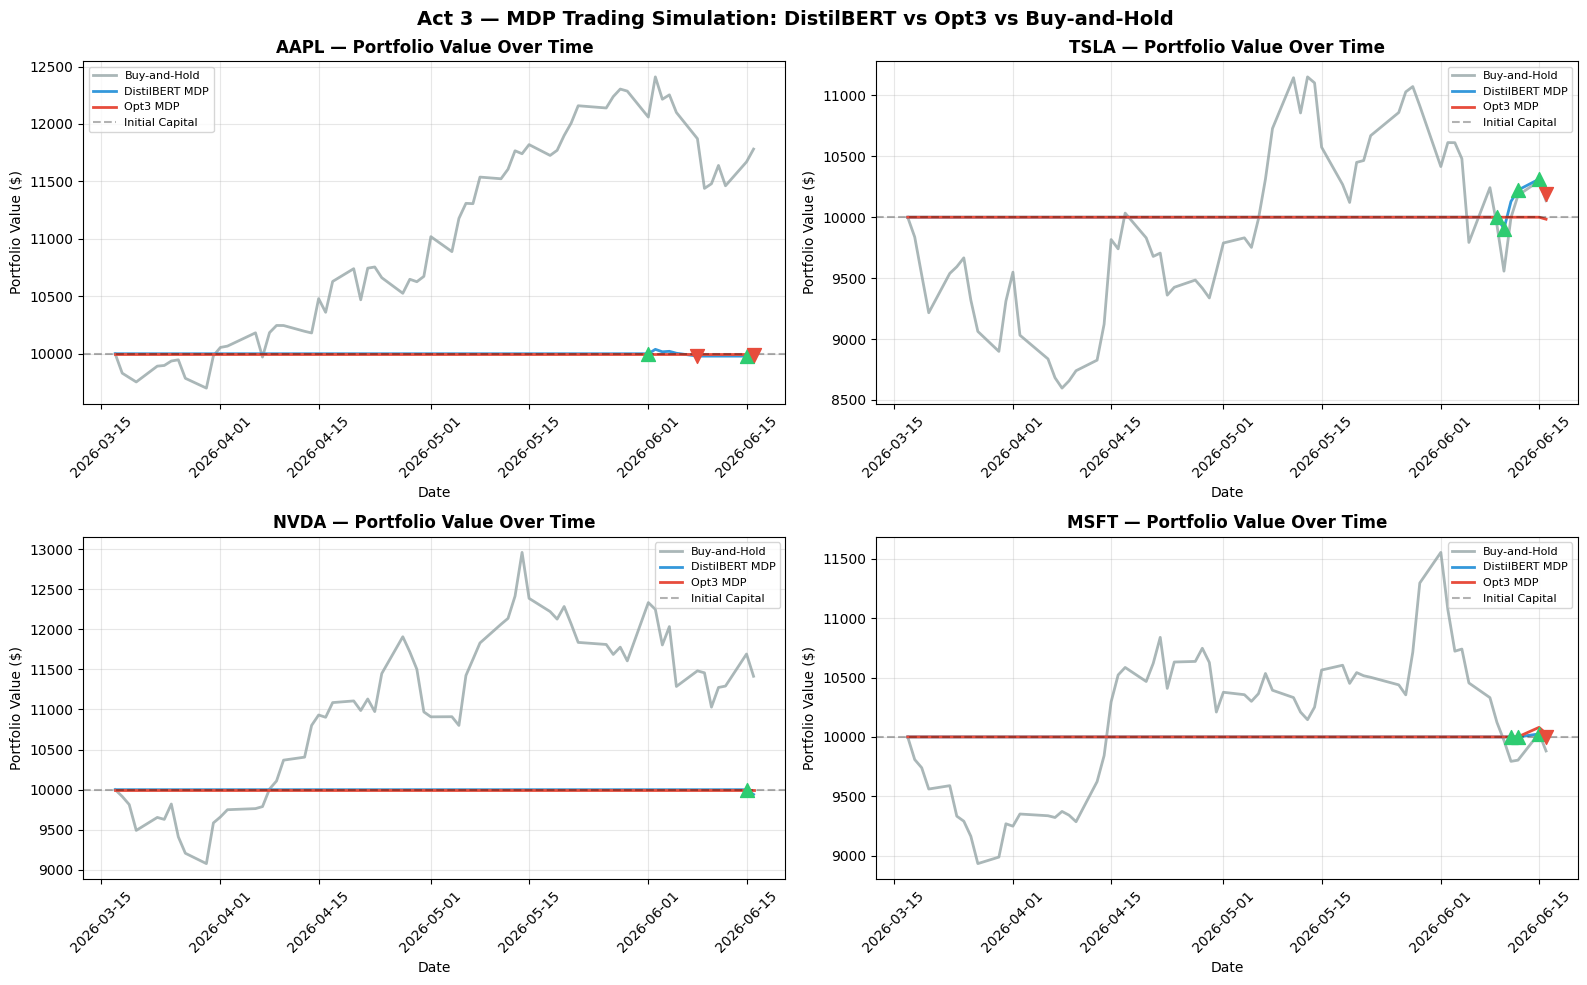

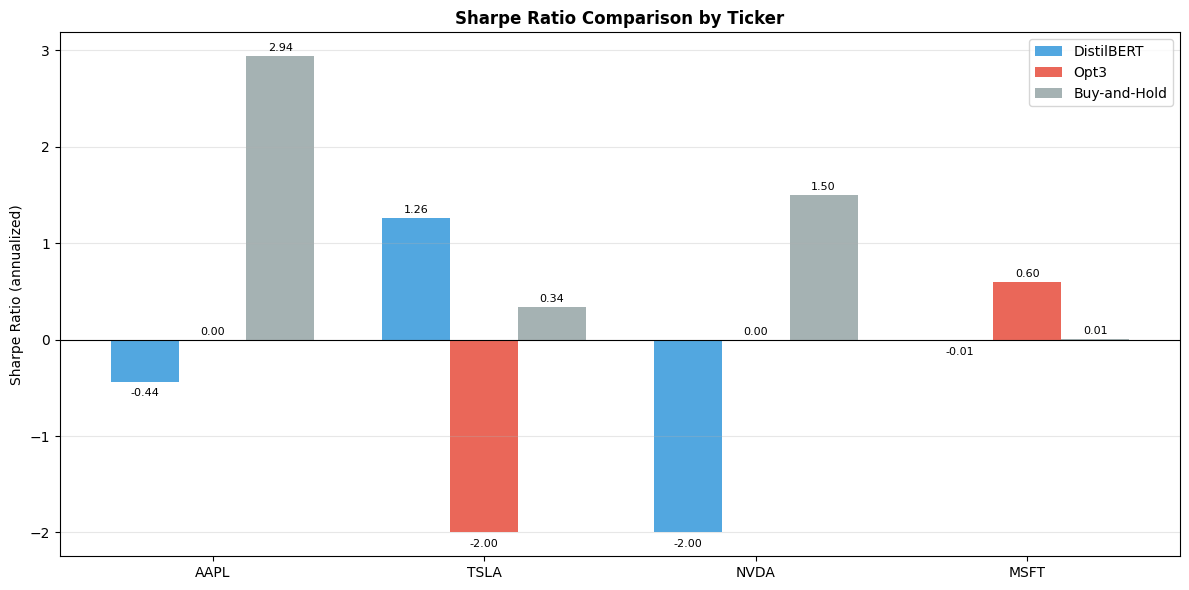

Full Trade Log — DistilBERT MDP Strategy:

AAPL:
  2026-06-01  BUY   Portfolio value after: $10,000.00
  2026-06-08  SELL  Portfolio value after: $9,979.37
  2026-06-15  BUY   Portfolio value after: $9,979.37
  2026-06-16  SELL  Portfolio value after: $9,987.87

TSLA:
  2026-06-09  BUY   Portfolio value after: $10,000.00
  2026-06-10  BUY   Portfolio value after: $9,904.90
  2026-06-12  BUY   Portfolio value after: $10,222.64
  2026-06-15  BUY   Portfolio value after: $10,312.70
  2026-06-16  SELL  Portfolio value after: $10,188.87

NVDA:
  2026-06-15  BUY   Portfolio value after: $10,000.00

MSFT:
  2026-06-11  BUY   Portfolio value after: $10,000.00
  2026-06-12  BUY   Portfolio value after: $10,000.57
  2026-06-15  BUY   Portfolio value after: $10,025.05
  2026-06-16  SELL  Portfolio value after: $9,999.81



In [ ]:
# Step 9 — Visualize portfolio value over time + trade log

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]

    ax.plot(results_bnh[ticker]['date'], results_bnh[ticker]['total_value'],
            label='Buy-and-Hold', color='#95A5A6', linewidth=2, alpha=0.8)
    ax.plot(results_bert[ticker]['date'], results_bert[ticker]['total_value'],
            label='DistilBERT MDP', color='#3498DB', linewidth=2)
    ax.plot(results_opt3[ticker]['date'], results_opt3[ticker]['total_value'],
            label='Opt3 MDP', color='#E74C3C', linewidth=2)

    # mark BUY/SELL trades from the DistilBERT strategy
    bert_trades = results_bert[ticker][results_bert[ticker]['action'] != 'HOLD']
    for _, t in bert_trades.iterrows():
        marker = '^' if t['action'] == 'BUY' else 'v'
        color = '#2ECC71' if t['action'] == 'BUY' else '#E74C3C'
        ax.scatter(t['date'], t['total_value'], marker=marker, color=color, s=100, zorder=5)

    ax.axhline(y=INITIAL_CAPITAL, color='black', linestyle='--', alpha=0.3, label='Initial Capital')
    ax.set_title(f'{ticker} — Portfolio Value Over Time', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Portfolio Value ($)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Act 3 — MDP Trading Simulation: DistilBERT vs Opt3 vs Buy-and-Hold',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ── Sharpe Ratio comparison bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

strategies = ['DistilBERT', 'Opt3', 'Buy-and-Hold']
colors = ['#3498DB', '#E74C3C', '#95A5A6']
x = np.arange(len(TICKERS))
width = 0.25

for i, (strategy, color) in enumerate(zip(strategies, colors)):
    vals = [sharpe_results[t][strategy] for t in TICKERS]
    bars = ax.bar(x + i*width, vals, width, label=strategy, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + (0.05 if h >= 0 else -0.15),
                f'{h:.2f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(TICKERS)
ax.set_ylabel('Sharpe Ratio (annualized)')
ax.set_title('Sharpe Ratio Comparison by Ticker', fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# ── Combined trade log across all tickers ──────────────────────────────────
print("Full Trade Log — DistilBERT MDP Strategy:\n")
for ticker in TICKERS:
    trades = results_bert[ticker][results_bert[ticker]['action'] != 'HOLD']
    if len(trades) == 0:
        print(f"{ticker}: no trades executed\n")
        continue
    print(f"{ticker}:")
    for _, t in trades.iterrows():
        print(f"  {t['date'].date()}  {t['action']:<4}  Portfolio value after: ${t['total_value']:,.2f}")
    print()

In [ ]:
# ── Section 13: Save Checkpoints (extended for Act 3) ──────────────────────────
import os, joblib
import numpy as np
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

SAVE_DIR = '/content/drive/MyDrive/NLPQ/checkpoints/'
os.makedirs(SAVE_DIR, exist_ok=True)

print('Saving checkpoints to Google Drive...')

# ── Basic models (Act 1) ───────────────────────────────────────────────────────
joblib.dump(vectorizer,   SAVE_DIR + 'tfidf_vectorizer.pkl')
joblib.dump(model_lr,     SAVE_DIR + 'model_lr.pkl')
joblib.dump(model_svm,    SAVE_DIR + 'model_svm.pkl')
joblib.dump(model_mnb,    SAVE_DIR + 'model_mnb.pkl')
joblib.dump(meta_learner, SAVE_DIR + 'meta_learner.pkl')
joblib.dump(le,           SAVE_DIR + 'label_encoder.pkl')
print('Basic Models saved')

# ── BiLSTM ───────────────────────────────────────────────────────────────────
model_bilstm.save(SAVE_DIR + 'bilstm_model.keras')
joblib.dump(keras_tokenizer, SAVE_DIR + 'keras_tokenizer.pkl')
print('BiLSTM + Keras saved')

# ── DistilBERT (single consolidated folder) ────────────────────────────────────
model_distilbert.save_pretrained(SAVE_DIR + 'distilbert_model')
bert_tokenizer.save_pretrained(SAVE_DIR + 'distilbert_model')
print('DistilBERT saved')

# ── Probability arrays + labels (Act 1/2) ──────────────────────────────────────
np.save(SAVE_DIR + 'prob_distilbert.npy', prob_distilbert)
np.save(SAVE_DIR + 'prob_bilstm.npy', prob_bilstm)
np.save(SAVE_DIR + 'y_test.npy', y_test)
np.save(SAVE_DIR + 'y_train.npy', y_train)
print('Probability arrays saved')

# ── Text arrays (Act 1) ────────────────────────────────────────────────────────
joblib.dump(X_text_train.tolist(), SAVE_DIR + 'X_text_train.pkl')
joblib.dump(X_text_test.tolist(), SAVE_DIR + 'X_text_test.pkl')
print('Text arrays saved')

# ── NEW: Act 3 — price data ────────────────────────────────────────────────────
joblib.dump(price_data, SAVE_DIR + 'price_data.pkl')
print('Price data saved')

# ── NEW: Act 3 — headlines (raw, matched, filtered) ────────────────────────────
joblib.dump(all_headlines,      SAVE_DIR + 'all_headlines.pkl')
joblib.dump(matched_headline,  SAVE_DIR + 'matched_headlines.pkl')
joblib.dump(filtered_bert,      SAVE_DIR + 'filtered_bert.pkl')
joblib.dump(filtered_opt3,      SAVE_DIR + 'filtered_opt3.pkl')
print('Headlines (raw/matched/filtered) saved')

# ── NEW: Act 3 — aggregated daily signals ──────────────────────────────────────
joblib.dump(daily_signals_bert, SAVE_DIR + 'daily_signals_bert.pkl')
joblib.dump(daily_signals_opt3, SAVE_DIR + 'daily_signals_opt3.pkl')
print('Daily signals saved')

# ── NEW: Act 3 — Kelly sizing ───────────────────────────────────────────────────
joblib.dump(b_values,           SAVE_DIR + 'b_values.pkl')
joblib.dump(kelly_signals_bert, SAVE_DIR + 'kelly_signals_bert.pkl')
joblib.dump(kelly_signals_opt3, SAVE_DIR + 'kelly_signals_opt3.pkl')
print('Kelly sizing saved')

# ── NEW: Act 3 — simulation results ─────────────────────────────────────────────
joblib.dump(results_bert, SAVE_DIR + 'results_bert.pkl')
joblib.dump(results_opt3, SAVE_DIR + 'results_opt3.pkl')
joblib.dump(results_bnh,  SAVE_DIR + 'results_bnh.pkl')
joblib.dump(trade_logs,   SAVE_DIR + 'trade_logs.pkl')
print('Simulation results saved')

# ── NEW: Act 3 — Sharpe Ratios ──────────────────────────────────────────────────
joblib.dump(sharpe_results, SAVE_DIR + 'sharpe_results.pkl')
print('Sharpe results saved')

print()
print('All checkpoints saved!')
for f in sorted(os.listdir(SAVE_DIR)):
    full_path = SAVE_DIR + f
    if os.path.isdir(full_path):
        print(f'  {f:<45} (folder)')
    else:
        size_kb = os.path.getsize(full_path) / 1024
        print(f'  {f:<45} {size_kb:>8.1f} KB')

Mounted at /content/drive
Saving checkpoints to Google Drive...
Basic Models saved
BiLSTM + Keras saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT saved
Probability arrays saved
Text arrays saved
Price data saved
Headlines (raw/matched/filtered) saved
Daily signals saved
Kelly sizing saved
Simulation results saved
Sharpe results saved

All checkpoints saved!
  X_text_test.pk1                                  154.0 KB
  X_text_test.pkl                                  154.0 KB
  X_text_train.pk1                                 604.7 KB
  X_text_train.pkl                                 604.7 KB
  all_headlines.pkl                                 50.2 KB
  b_values.pkl                                       0.2 KB
  bilstm_model.keras                              3719.3 KB
  daily_signals_bert.pkl                            14.2 KB
  daily_signals_opt3.pkl                            15.2 KB
  distilbert_findtuned                          (folder)
  distilbert_model                              (folder)
  filtered_bert.pkl                                 47.7 KB
  filtered_opt3.pkl                                 51.9 KB
 

In [ ]:
# Clean up old .pk1 typo files and the redundant distilbert_findtuned folder

import shutil

old_pk1_files = [f for f in os.listdir(SAVE_DIR) if f.endswith('.pk1')]

print(f"Removing {len(old_pk1_files)} old .pk1 files:")
for f in old_pk1_files:
    os.remove(SAVE_DIR + f)
    print(f"  removed: {f}")

# remove the old incomplete distilbert folder too (the consolidated one is 'distilbert_model')
old_distilbert_folder = SAVE_DIR + 'distilbert_findtuned'
if os.path.exists(old_distilbert_folder):
    shutil.rmtree(old_distilbert_folder)
    print(f"  removed folder: distilbert_findtuned")

print("\nFinal checkpoint folder contents:")
for f in sorted(os.listdir(SAVE_DIR)):
    full_path = SAVE_DIR + f
    if os.path.isdir(full_path):
        print(f'  {f:<45} (folder)')
    else:
        size_kb = os.path.getsize(full_path) / 1024
        print(f'  {f:<45} {size_kb:>8.1f} KB')

Removing 9 old .pk1 files:
  removed: tfidf_vectorizer.pk1
  removed: model_lr.pk1
  removed: model_svm.pk1
  removed: model_mnb.pk1
  removed: meta_learner.pk1
  removed: label_encoder.pk1
  removed: keras_tokenizer.pk1
  removed: X_text_train.pk1
  removed: X_text_test.pk1
  removed folder: distilbert_findtuned

Final checkpoint folder contents:
  X_text_test.pkl                                  154.0 KB
  X_text_train.pkl                                 604.7 KB
  all_headlines.pkl                                 50.2 KB
  b_values.pkl                                       0.2 KB
  bilstm_model.keras                              3719.3 KB
  daily_signals_bert.pkl                            14.2 KB
  daily_signals_opt3.pkl                            15.2 KB
  distilbert_model                              (folder)
  filtered_bert.pkl                                 47.7 KB
  filtered_opt3.pkl                                 51.9 KB
  kelly_signals_bert.pkl                            1